---
title: "From Strings to Programs: A Practical Guide to Prompt Engineering & Optimization in Python"
date: 2025-09-06
author: Maxime Rivest
description: "LiteLLM → “roll‑your‑own” optimizer → DSPy (signatures, adapters, MIPROv2) → CoT & ReAct"
format:
  html:
    toc: true
    toc-location: right
    code-tools: true
    reference-location: margin
title-block-banner: false
title-block-style: none
execute:
  echo: true
  cache: true
  freeze: true
---

> **TL;DR**
> We’ll take a real, slightly messy task—extracting *before‑tax* and *after‑tax* totals from receipt images—and walk it from a brittle single prompt to a robust, testable **program**.
>
> * Start with **LiteLLM** + a vision model as a baseline.
> * Add **structured output** (Pydantic) + **evaluation** (a crisp metric).
> * Batch experiments with **Pixeltable**.
> * Build a **minimal automatic prompt optimizer** by hand (grounded in failing examples).
> * Switch to **DSPy** to get prompts-as-programs, signatures, adapters, and **MIPROv2** auto‑optimization.
> * Try **Chain‑of‑Thought** and **ReAct tools**; learn when they help—and when they don’t.
> * Finish with a simple **multi‑output** signature that guides reasoning; in our run this reached **11/11** with a larger model.

---

In [6]:
import litellm
import os

In [8]:
response = litellm.completion(
  model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
  messages=[{ "content": "Hello, how are you?","role": "user"}],
  api_key= os.environ["GROQ_API_KEY"] # this is not necessary but its to show you that you can provide you api key directly here
)
print(response.model_dump_json(indent=4))

{
    "id": "chatcmpl-8f134b77-3909-4dd5-b144-c1c148a33ec3",
    "created": 1756043843,
    "model": "meta-llama/llama-4-scout-17b-16e-instruct",
    "object": "chat.completion",
    "system_fingerprint": "fp_5436ed2ebe",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "message": {
                "content": "Hello! I'm just a language model, I don't have feelings like humans do, but I'm functioning properly and ready to help you with any questions or tasks you have! How can I assist you today?",
                "role": "assistant",
                "tool_calls": null,
                "function_call": null
            }
        }
    ],
    "usage": {
        "completion_tokens": 41,
        "prompt_tokens": 16,
        "total_tokens": 57,
        "completion_tokens_details": null,
        "prompt_tokens_details": null,
        "queue_time": 0.067231514,
        "prompt_time": 0.00256158,
        "completion_time": 0.096255738,
       

In [10]:
content_part1 = {
    "type": "text",
    "text": "Extract total and total before tax from the receipt"
}

In [13]:
from PIL import Image
import io
import base64

img = Image.open("images/receipts/IMG_2160.jpg").convert("RGB")
buf = io.BytesIO()
img.save(buf, format="JPEG")
b64 = base64.b64encode(buf.getvalue()).decode()

content_part2 = {
    "type": "image_url",
    "image_url": {
        "url": f"data:image/jpeg;base64,{b64}",
        "format": "image/jpeg"
    }
}

In [14]:
messages = [{
    "role": "user",
    "content": [content_part1,content_part2]
}]

In [16]:
response = litellm.completion(
  model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
  messages= messages,
  temperature = 0 
)
print(response.model_dump_json(indent=4))

{
    "id": "chatcmpl-59ce83db-741f-4139-bd20-8992f3bbd14c",
    "created": 1756044346,
    "model": "meta-llama/llama-4-scout-17b-16e-instruct",
    "object": "chat.completion",
    "system_fingerprint": "fp_38b31b7025",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "message": {
                "content": "The total amount is $45.10.\n\nThe amount before tax is not explicitly stated, but we can calculate it by subtracting the tax amounts from the total. \n\nThe TPS (tax) is $1.96 and the TVQ (tax) is $3.91. \n\nSo, the amount before tax is: \n$45.10 - $1.96 - $3.91 = $39.23. \n\nTherefore, the total is $45.10 and the total before tax is $39.23.",
                "role": "assistant",
                "tool_calls": null,
                "function_call": null
            }
        }
    ],
    "usage": {
        "completion_tokens": 108,
        "prompt_tokens": 1910,
        "total_tokens": 2018,
        "completion_tokens_details": n

In [17]:
45.10 - 1.96 - 3.91

39.230000000000004

In [18]:
content_part1 = {
    "type": "text",
    "text": """
Extract the after tax total and the before tax total from the receipt

Put these numbers in: <before_tax_total> and <after_tax_total> xml tags.
"""
}

response = litellm.completion(
  model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
  messages= [{
        "role": "user",
        "content": [content_part1,content_part2]
    }]
)
# Let's fetch only the actual llm response this time:
response.choices[0]["message"]["content"] # what a bad api :(

'To solve this problem, we need to identify the before-tax total and the after-tax total from the receipt.\n\nThe receipt shows:\n- Total cost before taxes for the fuel is not explicitly stated, but we can calculate it by subtracting the tax amounts from the total.\n- The TPS (tax) amount is $1.96.\n- The TVQ (tax) amount is $3.91.\n- The total cost after taxes is $45.10.\n\nFirst, let\'s calculate the before-tax total:\nBefore-tax total = After-tax total - (TPS + TVQ)\nBefore-tax total = $45.10 - ($1.96 + $3.91)  \nBefore-tax total = $45.10 - $5.87  \nBefore-tax total = $39.23  \n\nHowever, the receipt directly provides the before-tax total under "CARBURANT" as $45.10 - $5.87 (taxes) implies the subtotal is indeed $39.23 but let\'s verify with given data.\n\nThe before-tax total or subtotal is indeed $39.23 as calculated.\n\nThe after-tax total is given as $45.10.\n\nSo, the XML tags with the required information would be:\n\n<before_tax_total>$39.23</before_tax_total>\n<after_tax_tot

In [20]:
from pydantic import BaseModel, field_validator
from typing import Optional, Dict
import re

class ReceiptTotals(BaseModel):
    before_tax_total: Optional[float] = None
    after_tax_total:  Optional[float] = None

    @field_validator("*", mode="before")
    def _clean(cls, v):
        if v in (None, ""):
            return None
        cleaned = re.sub(r"[^\d.]", "", str(v))
        return float(cleaned) if cleaned else None

raw = response.choices[0]["message"]["content"]

before = re.search(r"<before_tax_total>(.*?)</before_tax_total>", raw).group(1)
after  = re.search(r"<after_tax_total>(.*?)</after_tax_total>",   raw).group(1)

pred = ReceiptTotals(before_tax_total=before, after_tax_total=after)
pred

ReceiptTotals(before_tax_total=39.23, after_tax_total=45.1)

In [21]:
pred.before_tax_total

39.23

In [23]:
def metric(ground_truth, pred):
    is_btax_same = ground_truth.before_tax_total == pred.before_tax_total
    is_atax_same = ground_truth.after_tax_total == pred.after_tax_total
    return float(is_btax_same and is_atax_same)

In [24]:
metric(
    ReceiptTotals(before_tax_total=39.23, after_tax_total=45.10),
    pred
)

1.0

Created directory 'tutoyt'.
Created table 'receipts'.
Inserting rows into `receipts`: 1 rows [00:00, 24.97 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 148.58 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 82.38 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 180.02 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 155.96 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 173.20 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 118.07 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 138.36 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 112.65 rows/s]
Inserted 1 row with 0 errors.
Inserting rows into `receipts`: 1 rows [00:00, 197.44 rows/s]
Inserted 1 row with 0 errors.


receipt_path,receipt_image
images/receipts/IMG_2160.jpg,
images/receipts/IMG_2163.jpg,
images/receipts/IMG_2166.jpg,

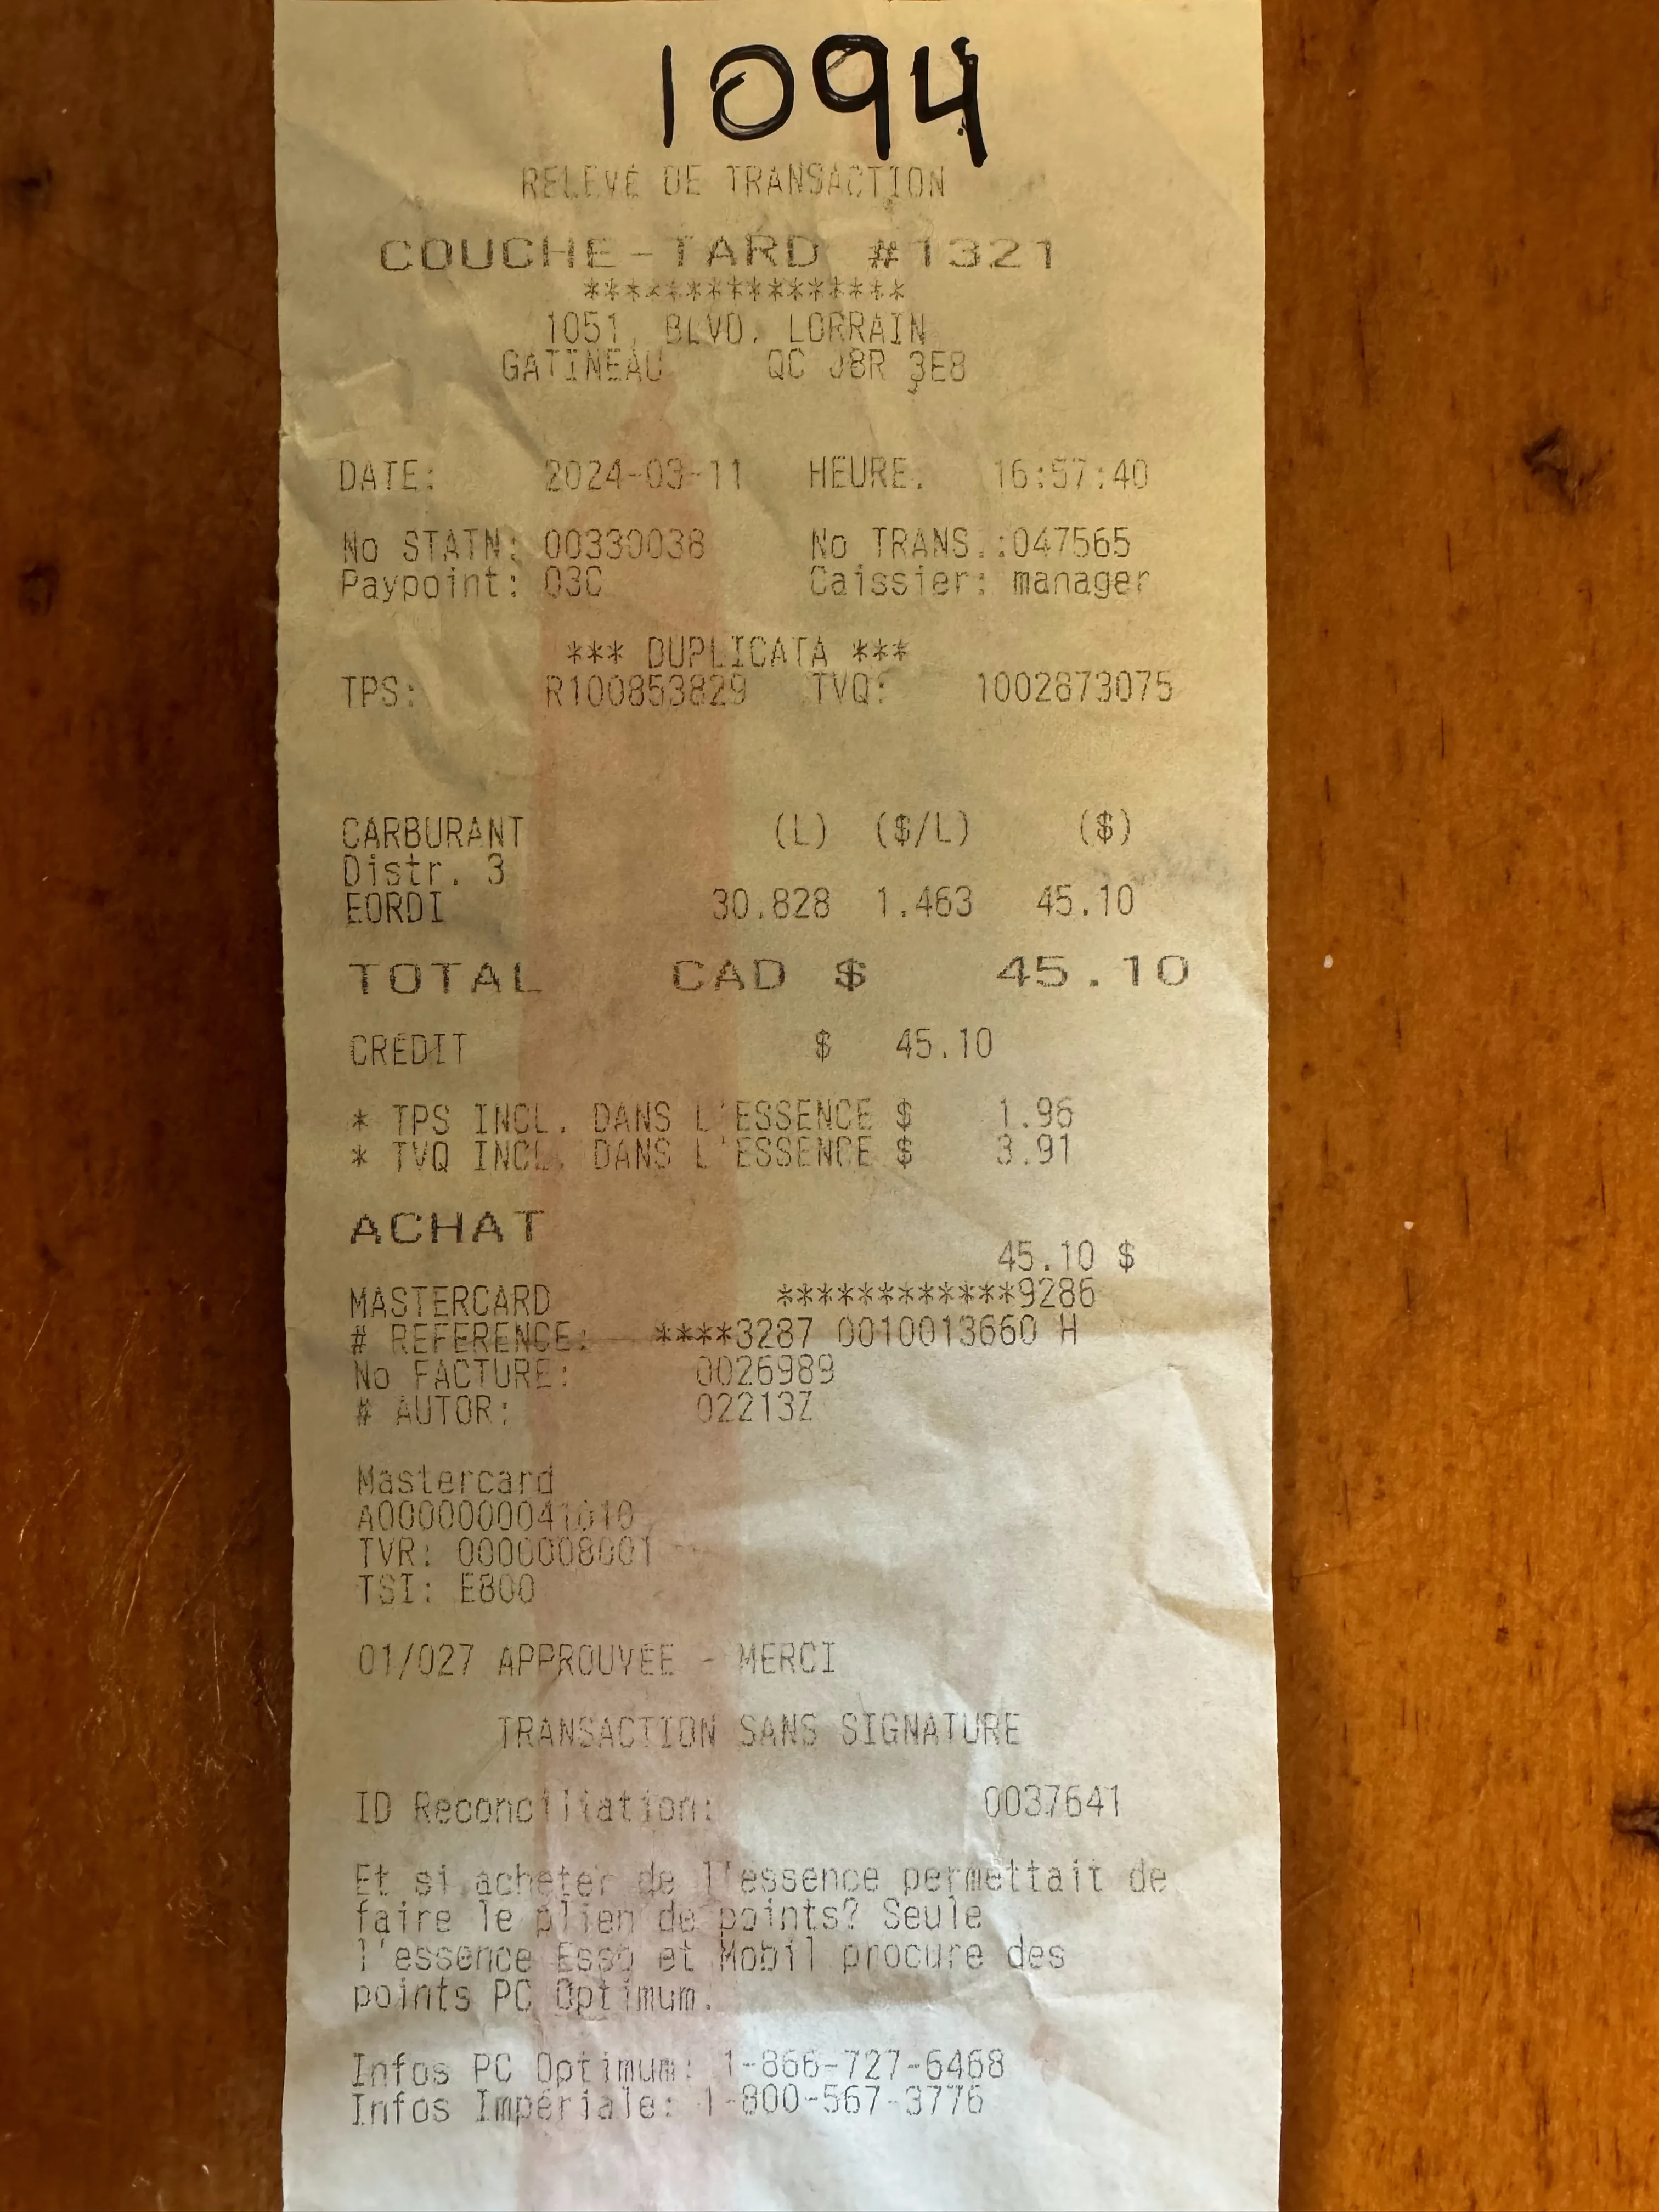
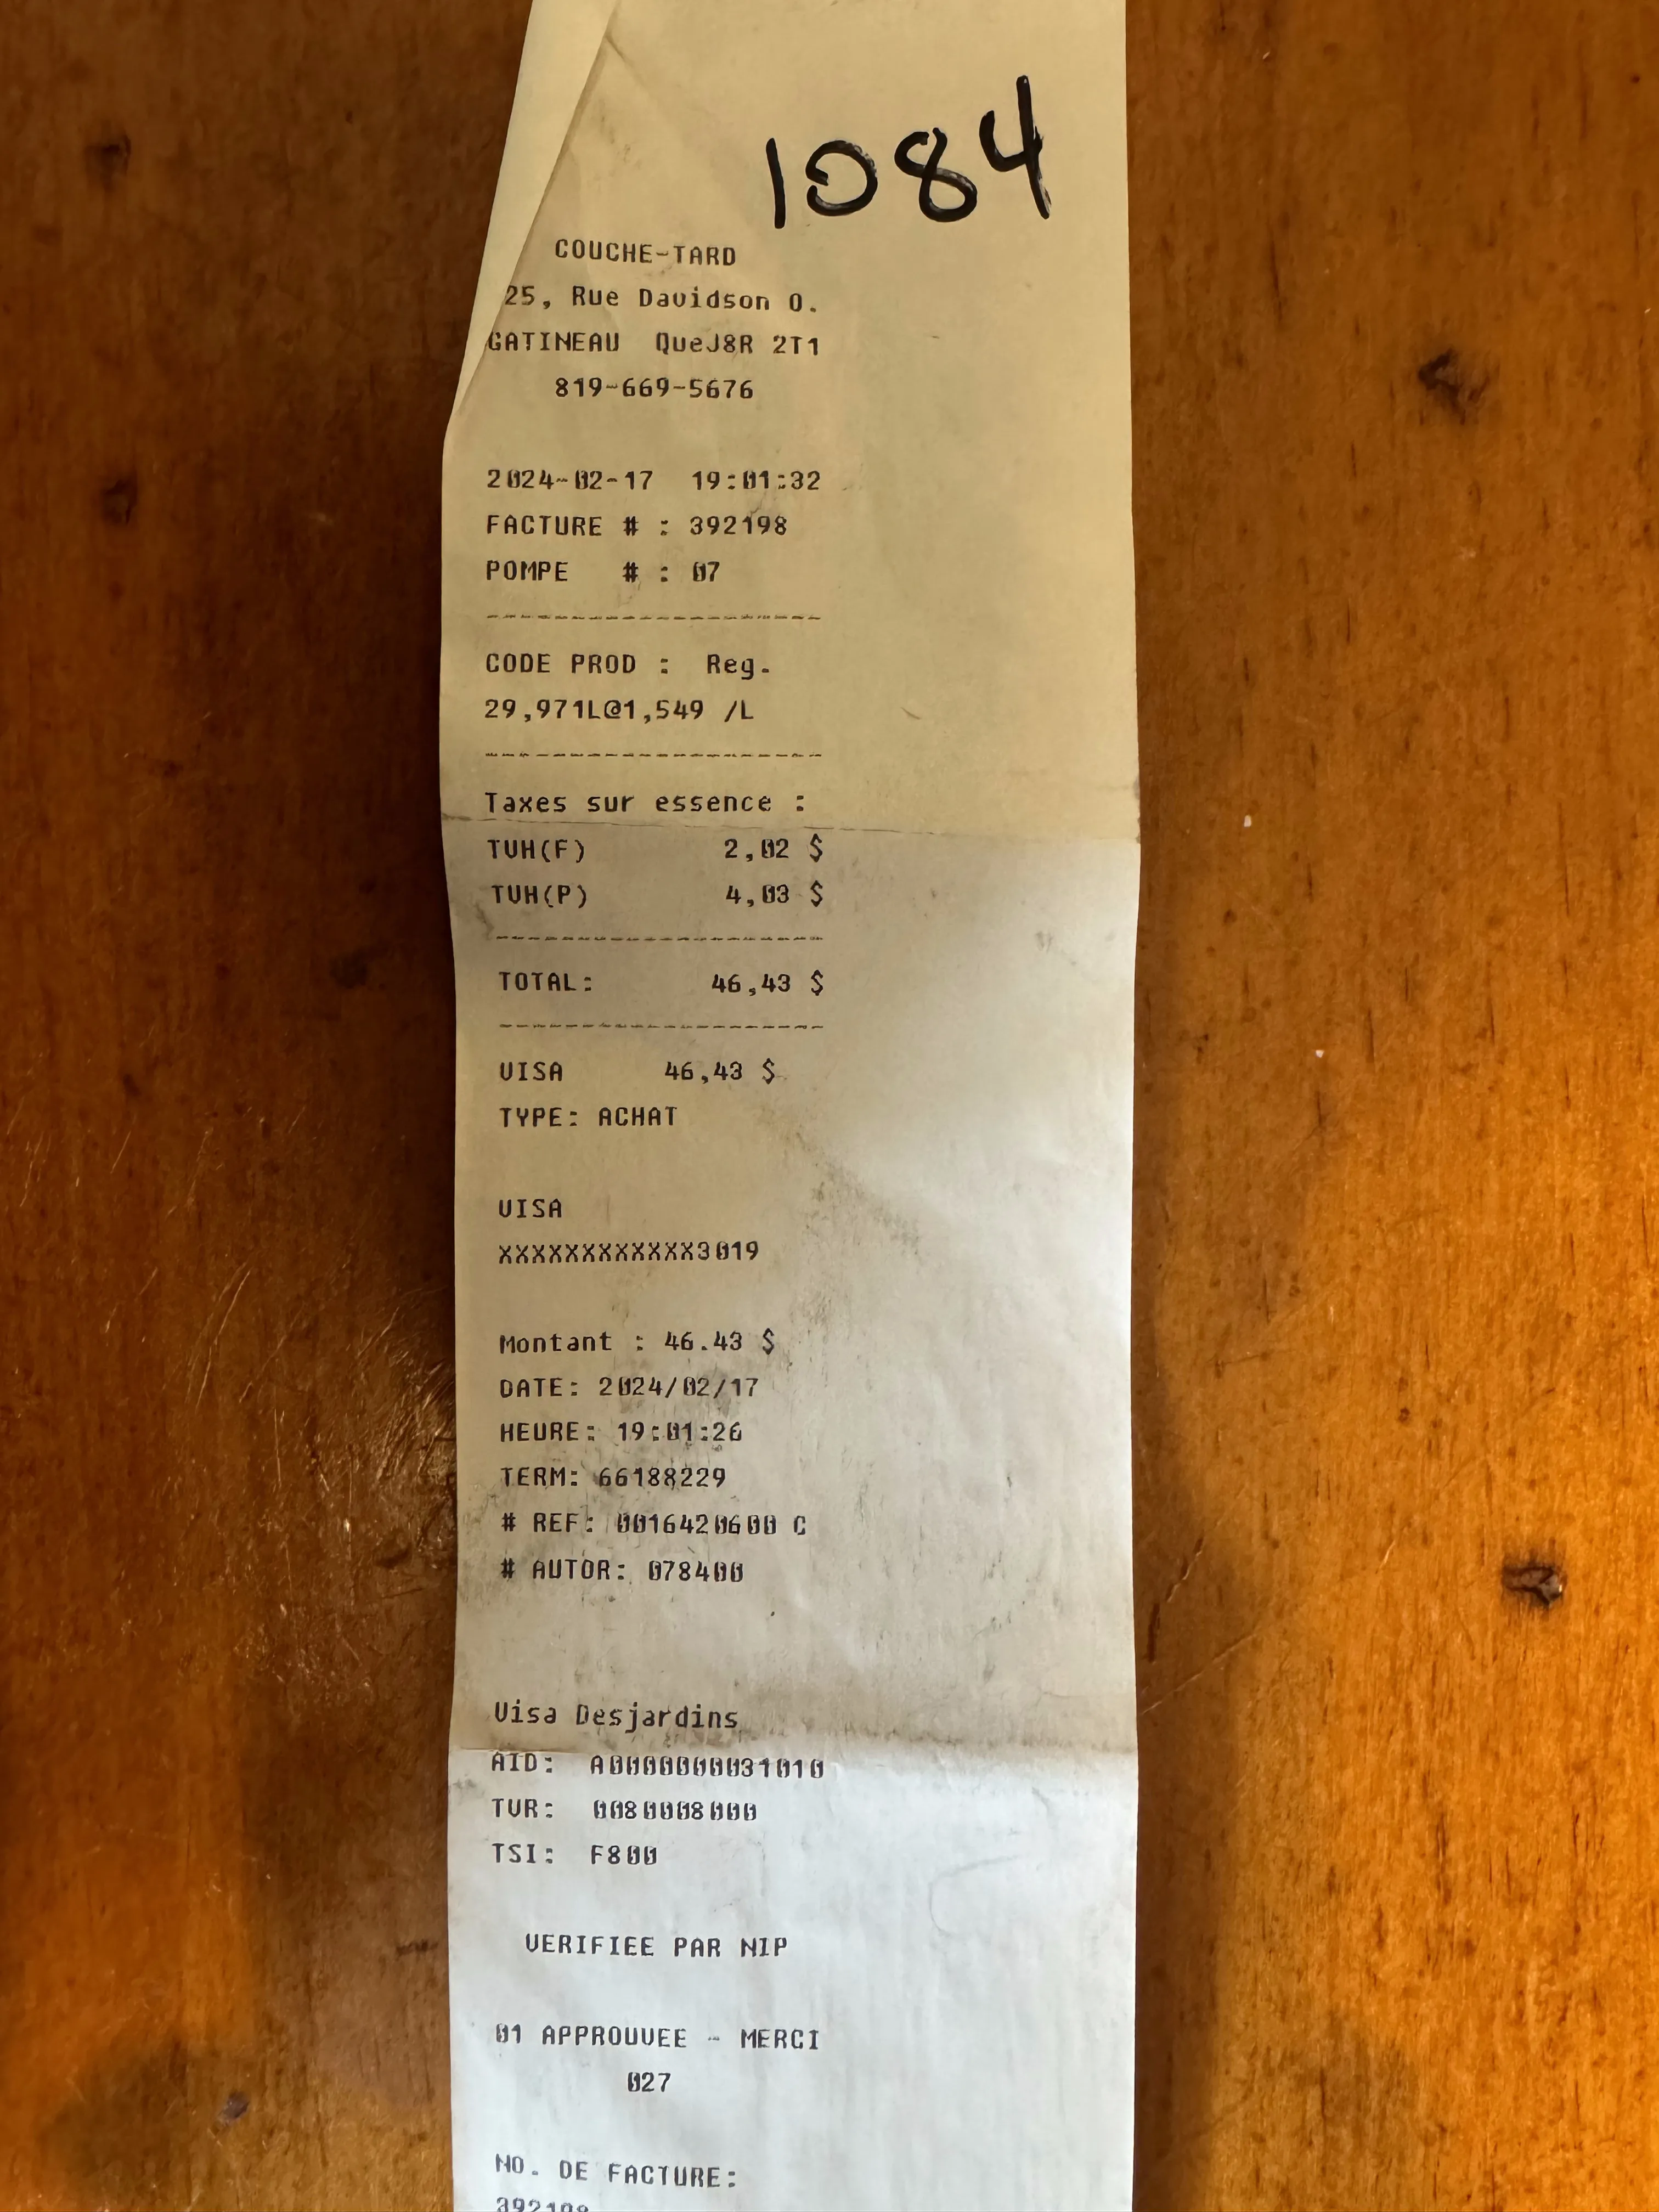
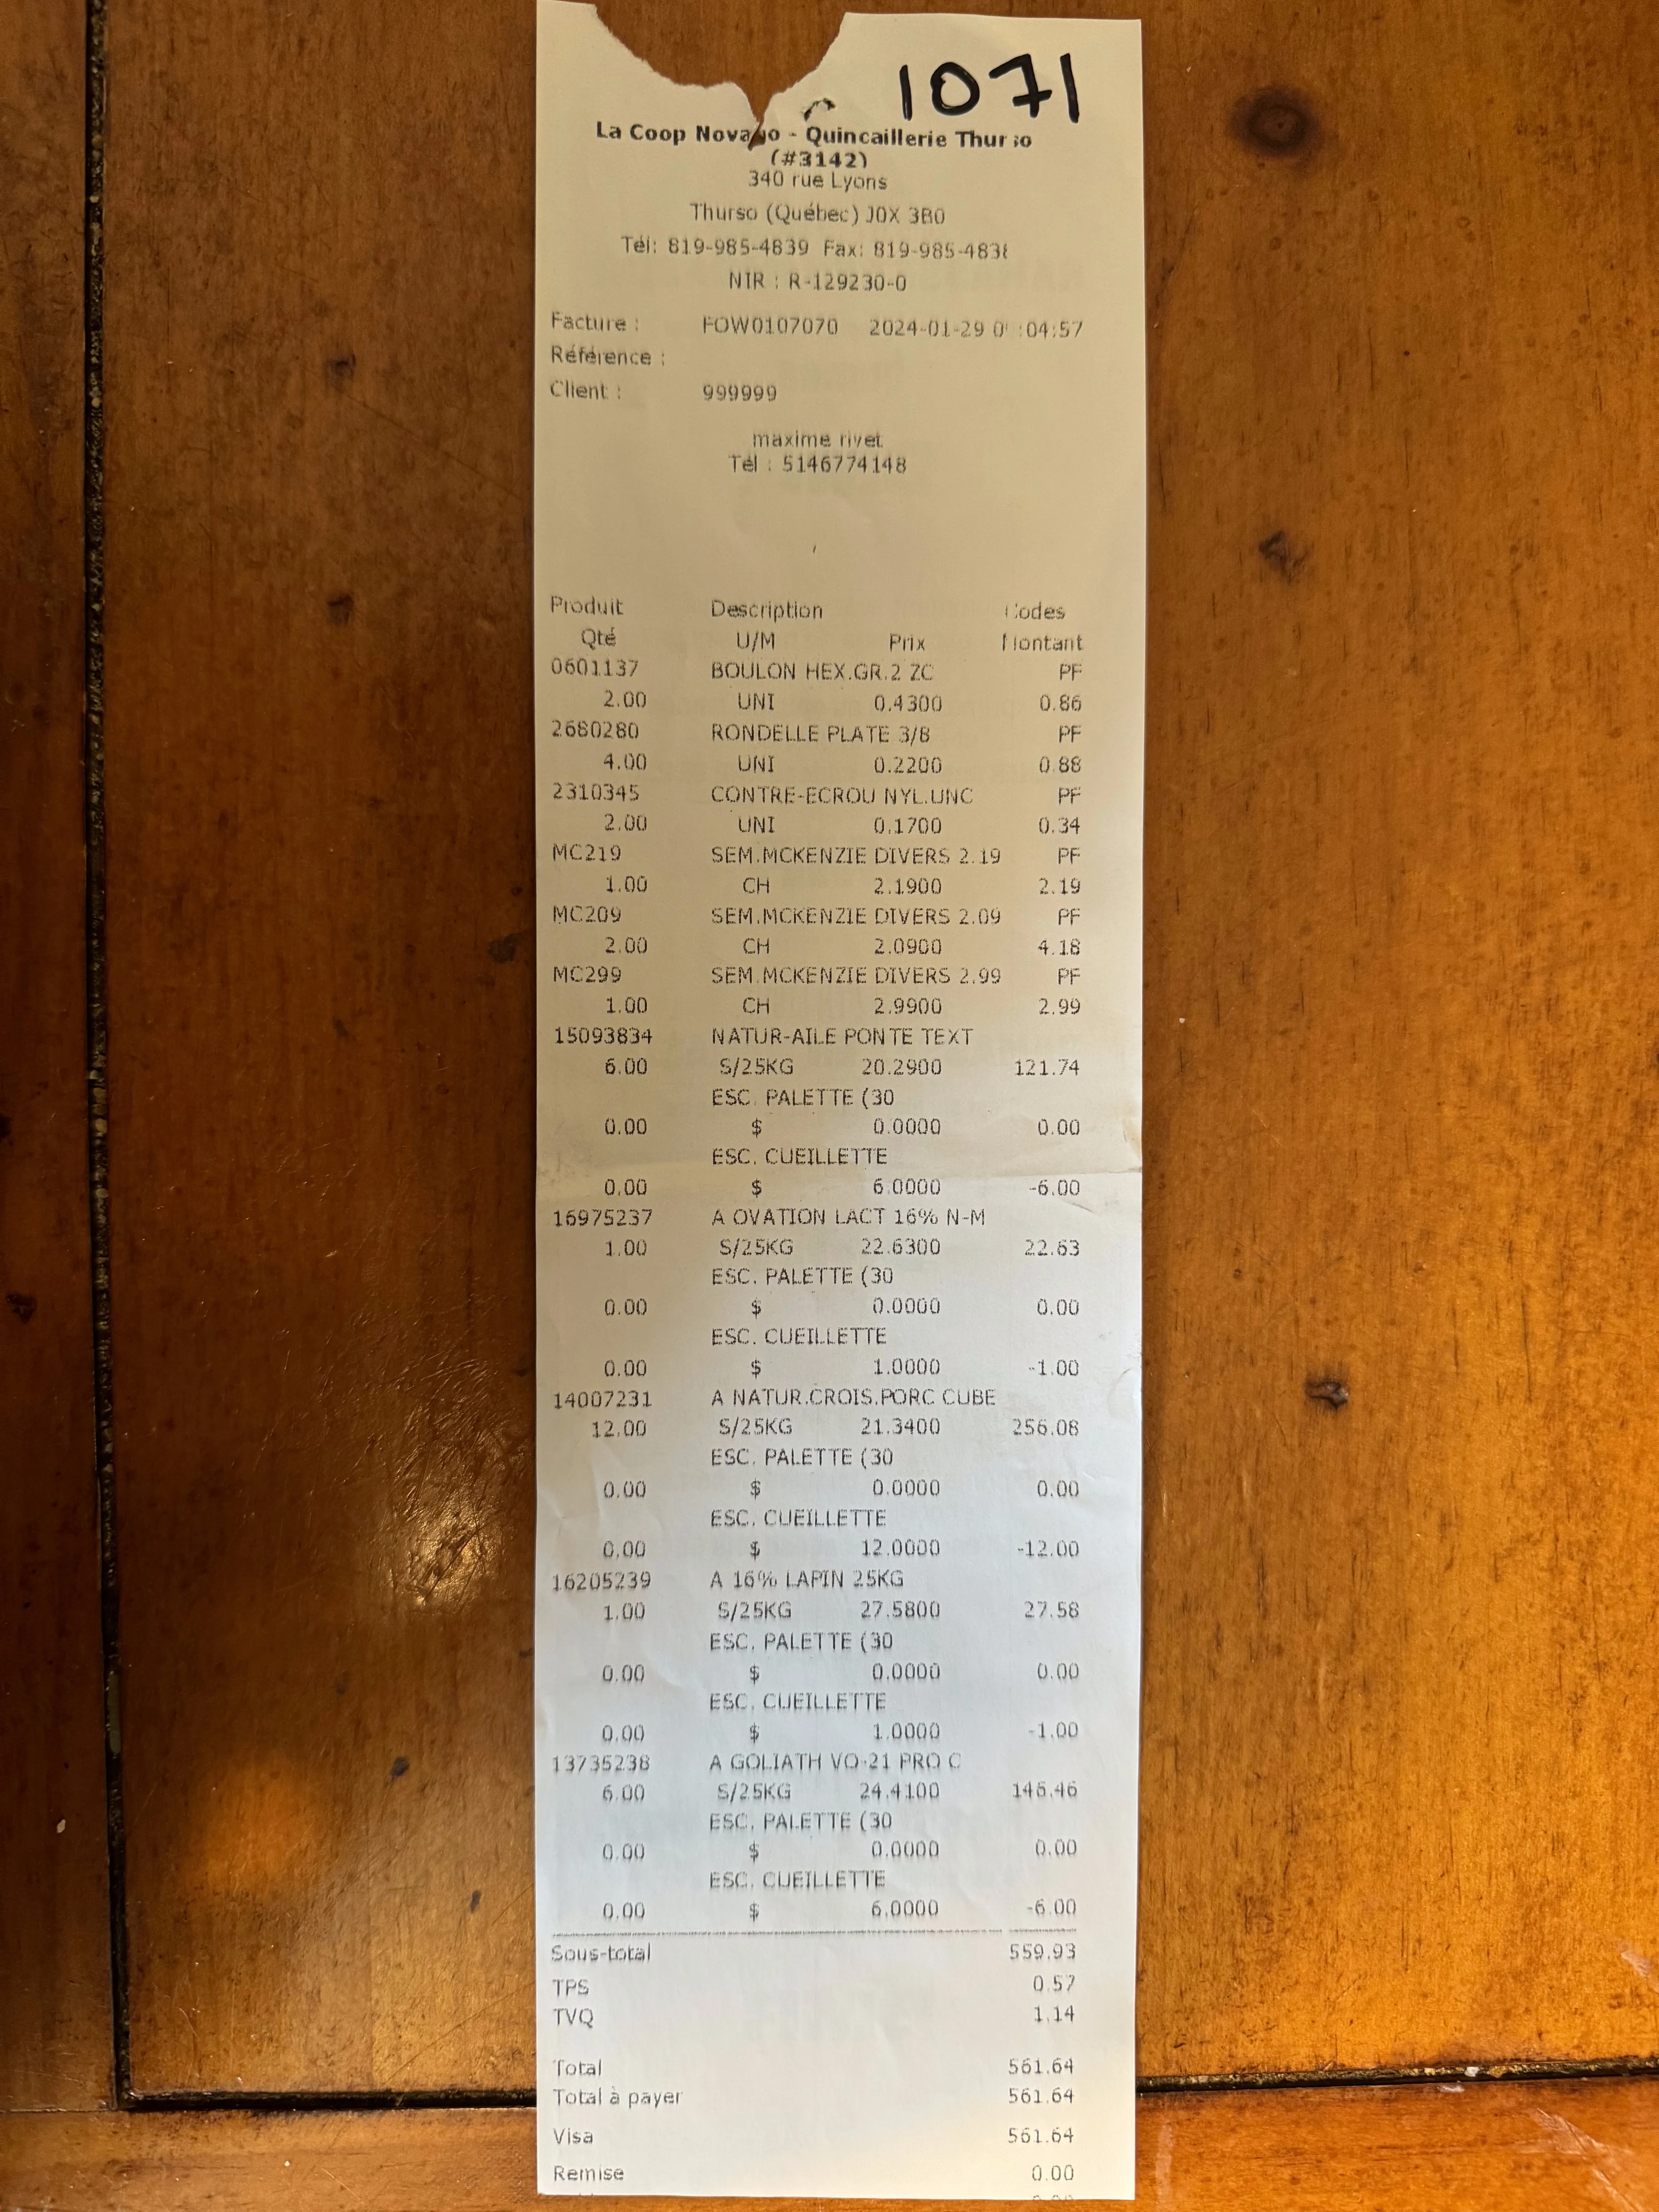

In [28]:
import pixeltable as pxt
from pixeltable import func
from pathlib import Path

pxt.drop_dir('tutoyt', force=True)
pxt.create_dir('tutoyt')

t = pxt.create_table('tutoyt.receipts',{
        'receipt_path': pxt.type_system.StringType(nullable=False),
        'receipt_image': pxt.Image
    },
    primary_key = 'receipt_path'
)

for p in Path('images/receipts').glob('*.jpg'):
    t.insert(receipt_path=str(p) ,receipt_image=str(p))

t.show(n=3)

In [29]:

def extract_totals(img: Image.Image) -> Dict[str, float]:
    """
    Extract the before-tax and after-tax totals from an receipt image.

    Parameters
    ----------
    img : PIL.Image.Image
        The receipt image (already decoded).

    Returns
    -------
    dict
        Keys: ``before_tax_total``, ``after_tax_total`` (as floats).
    """
    # --- 1. Encode image ---
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=95)
    b64 = base64.b64encode(buf.getvalue()).decode()

    # --- 2. Prompt ---
    prompt = (       
        "Extract the after-tax total and the before-tax total from the receipt.\n"
        "Return the values inside these XML tags:\n"
        "<before_tax_total>VALUE</before_tax_total>\n"
        "<after_tax_total>VALUE</after_tax_total>"
    )

    # --- 3. LLM call via LiteLLM ---
    response = litellm.completion(
        model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {
                    "url": f"data:image/jpeg;base64,{b64}"
                }}
            ]
        }],
        temperature=0
    )

    # --- 4. Parse & validate ---
    raw = response.choices[0]["message"]["content"]
    before = re.search(r"<before_tax_total>(.*?)</before_tax_total>", raw).group(1)
    after  = re.search(r"<after_tax_total>(.*?)</after_tax_total>", raw).group(1)
    return ReceiptTotals(before_tax_total=before, after_tax_total=after).model_dump()


In [30]:
extract_totals(Image.open("images/receipts/IMG_2167.jpg"))

{'before_tax_total': 88.74, 'after_tax_total': 100.4}

In [31]:
@pxt.udf
def extract_totals_udf(img: Image.Image) -> Dict[str, float]:
    return extract_totals(img)

t.add_computed_column(extraction = extract_totals_udf(t.receipt_image))

Added 10 column values with 0 errors.


10 rows updated, 10 values computed.

receipt_path,receipt_image,extraction
images/receipts/IMG_2160.jpg,,"{""after_tax_total"": 45.1, ""before_tax_total"": 45.1}"
images/receipts/IMG_2163.jpg,,"{""after_tax_total"": 46.43, ""before_tax_total"": 39.58}"
images/receipts/IMG_2166.jpg,,"{""after_tax_total"": 561.64, ""before_tax_total"": 559.93}"

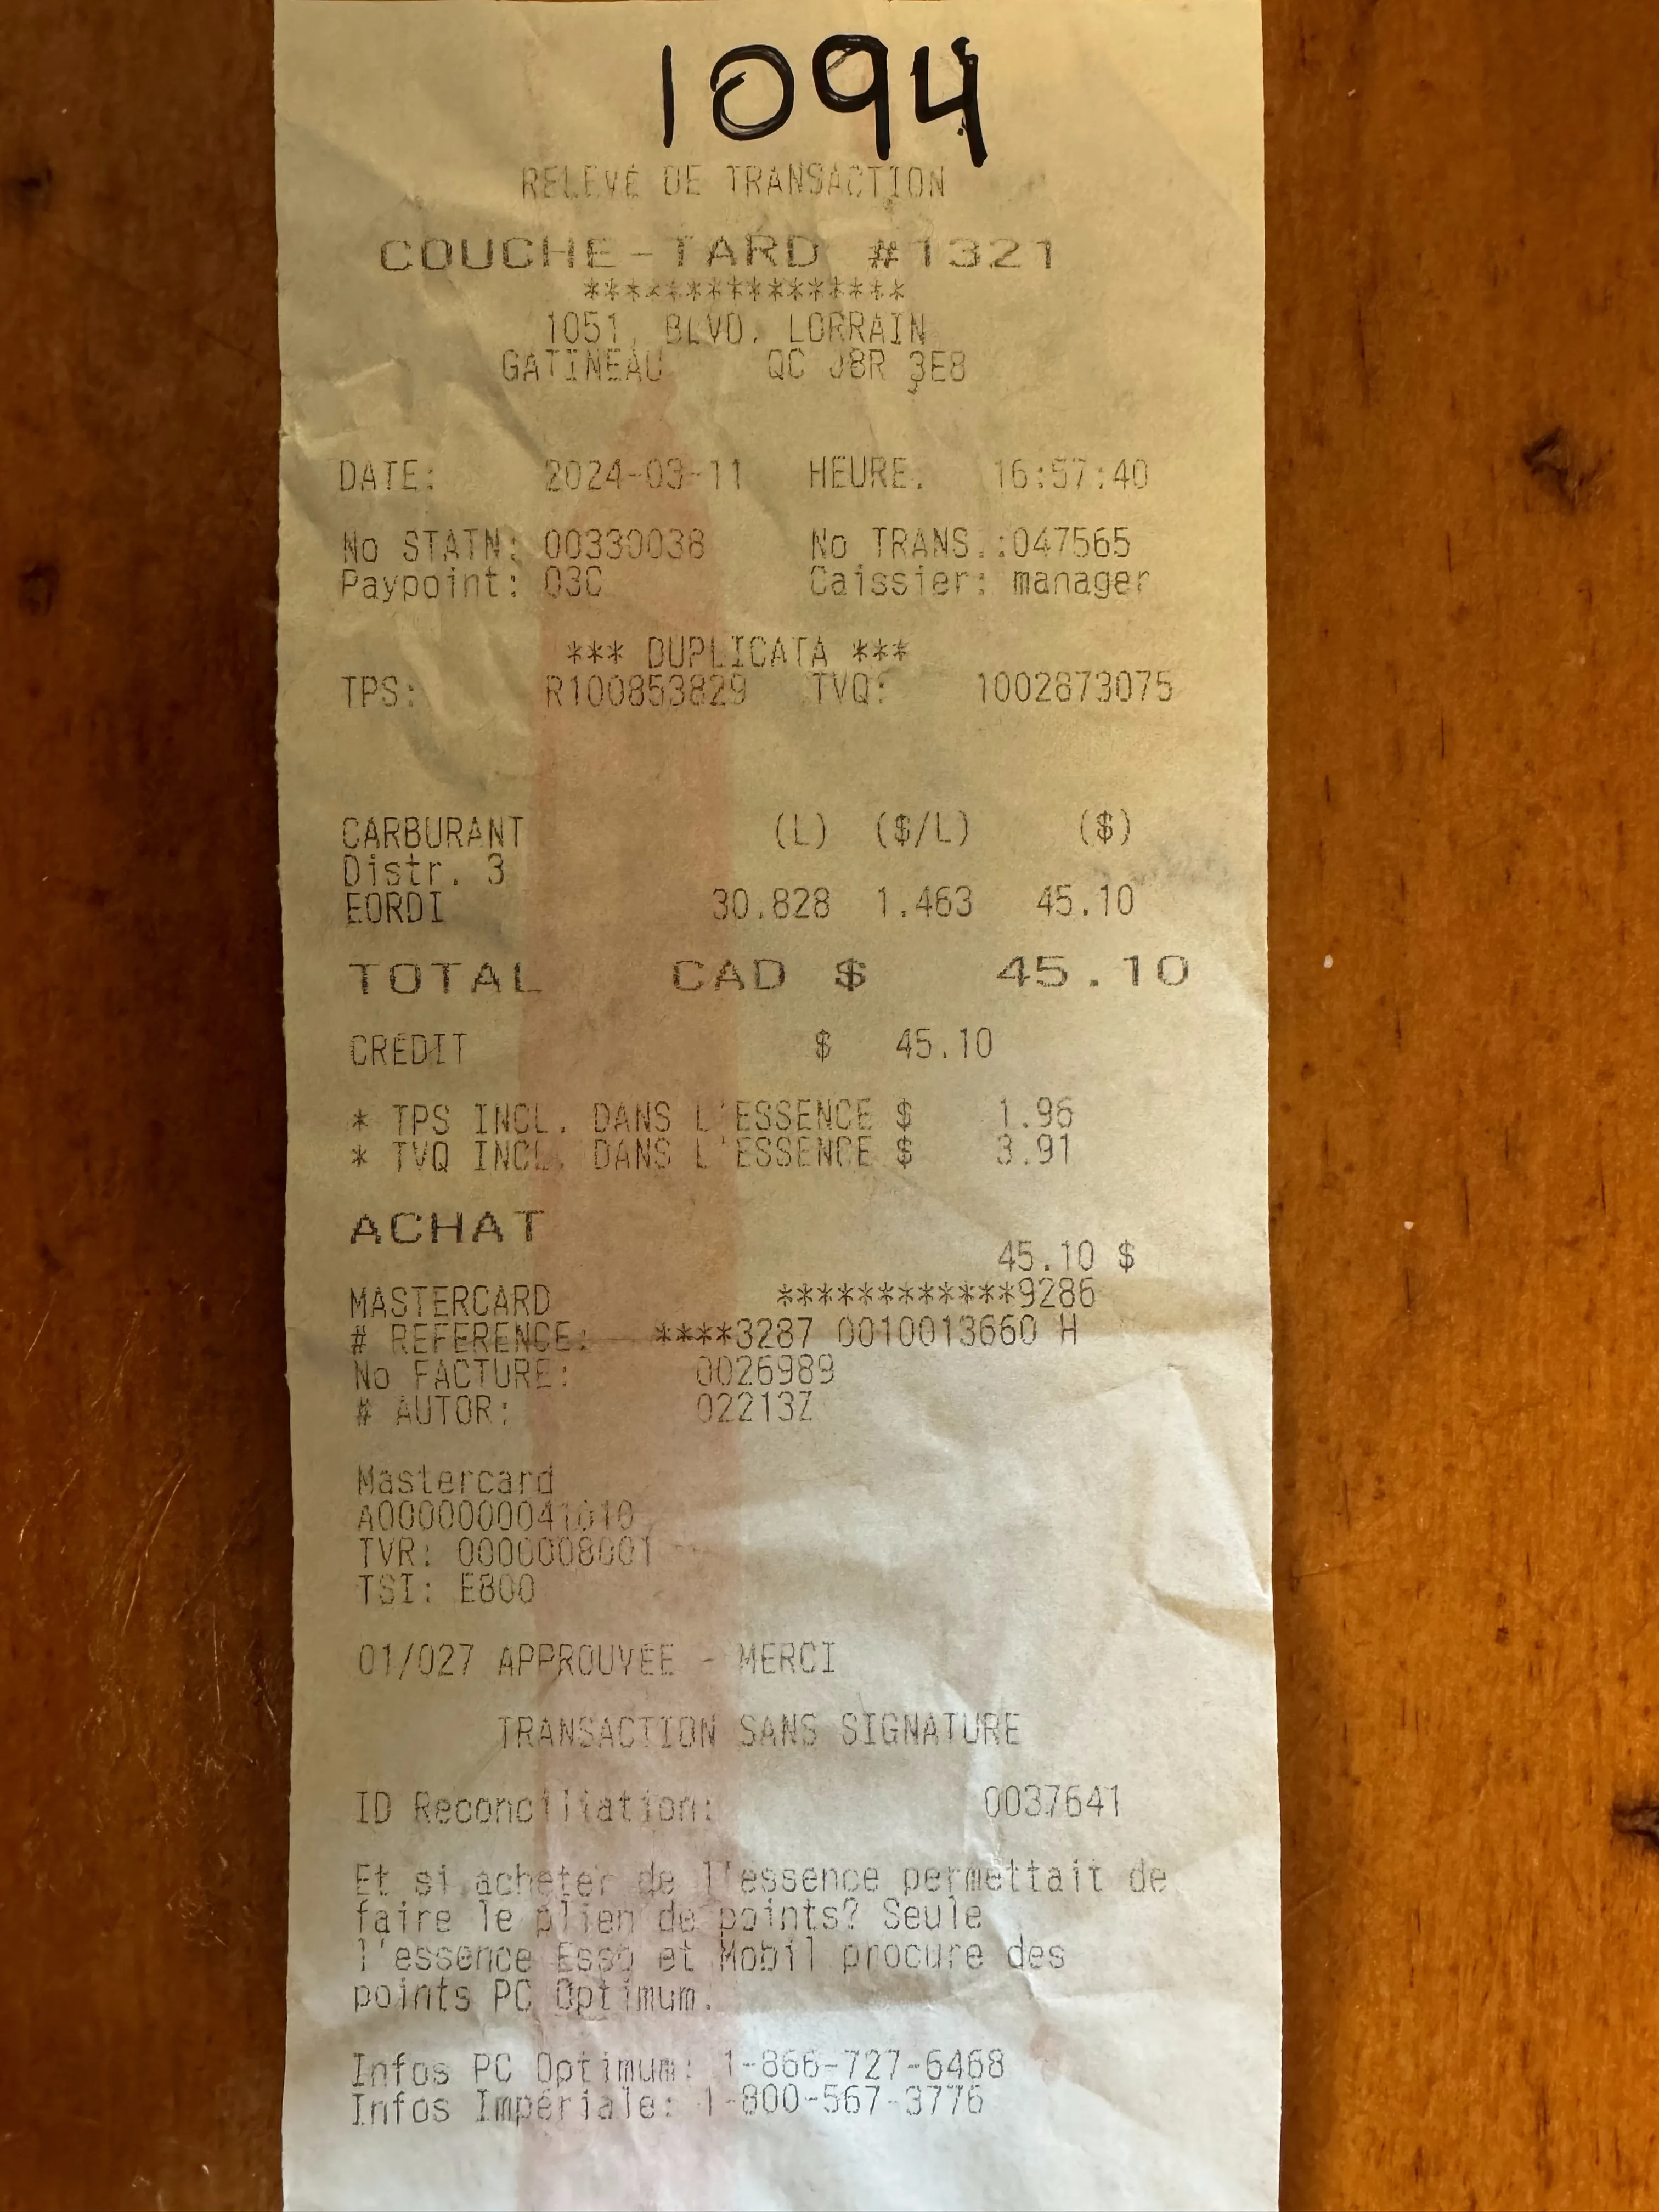
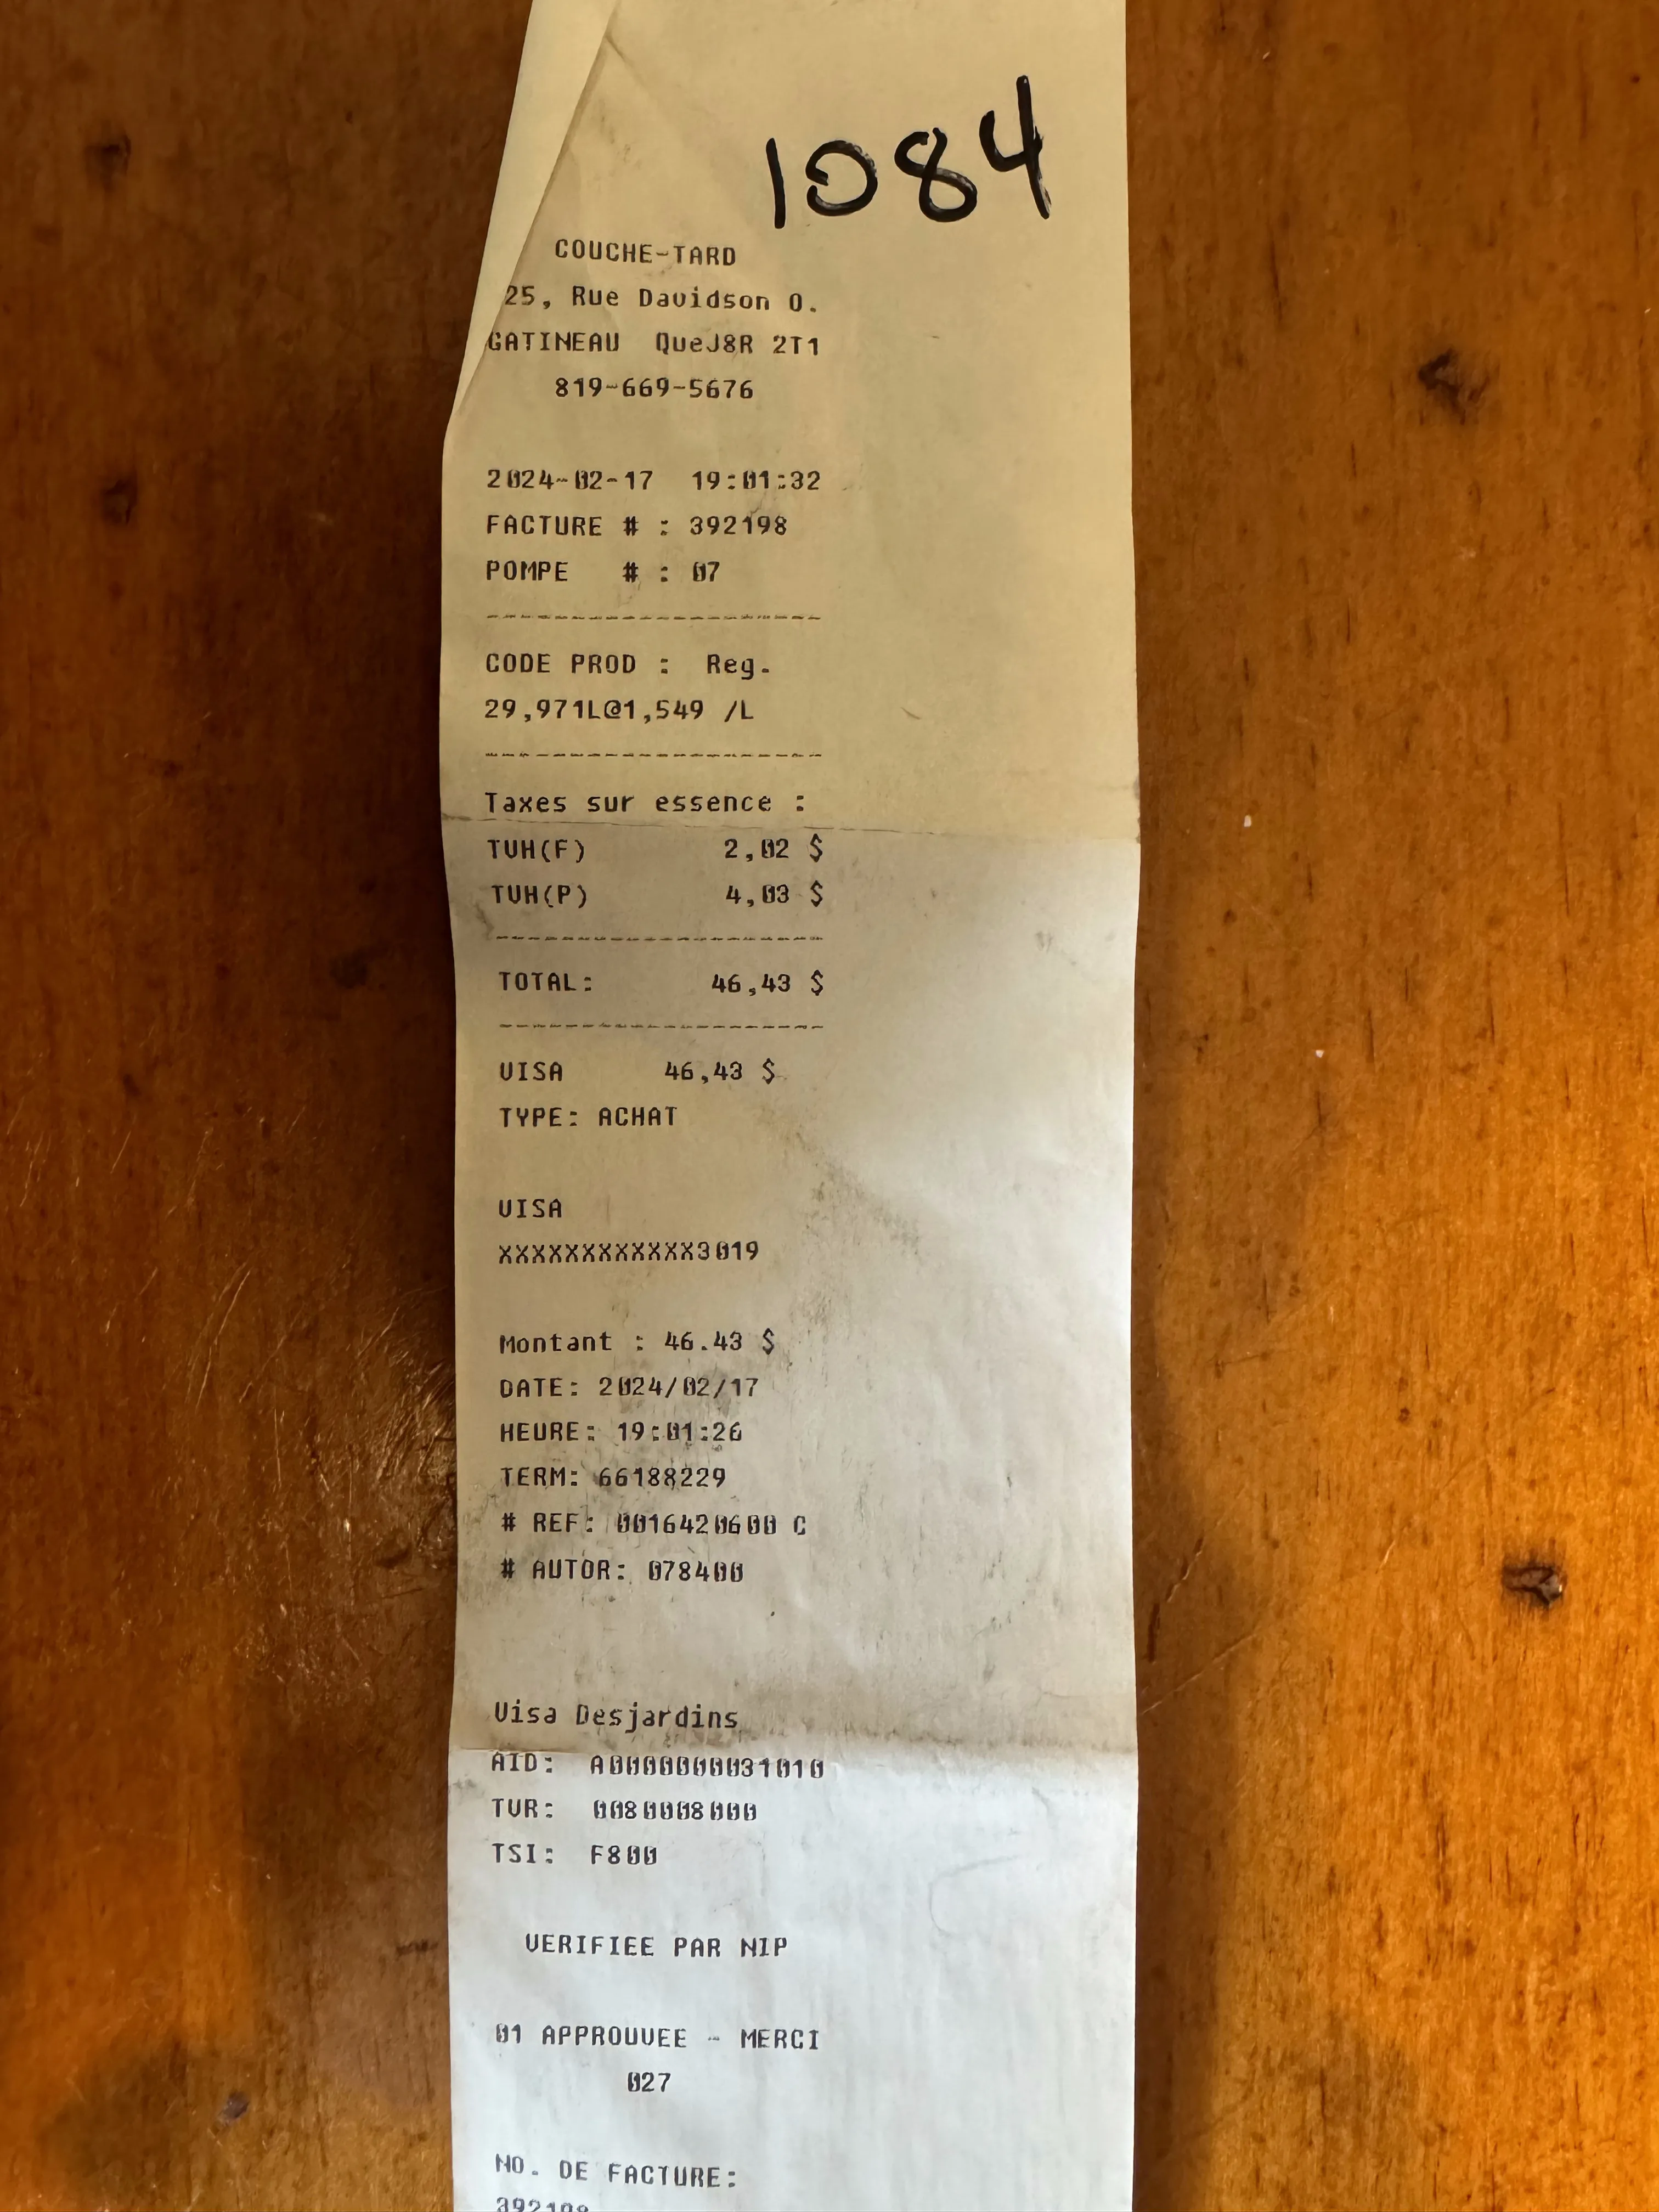
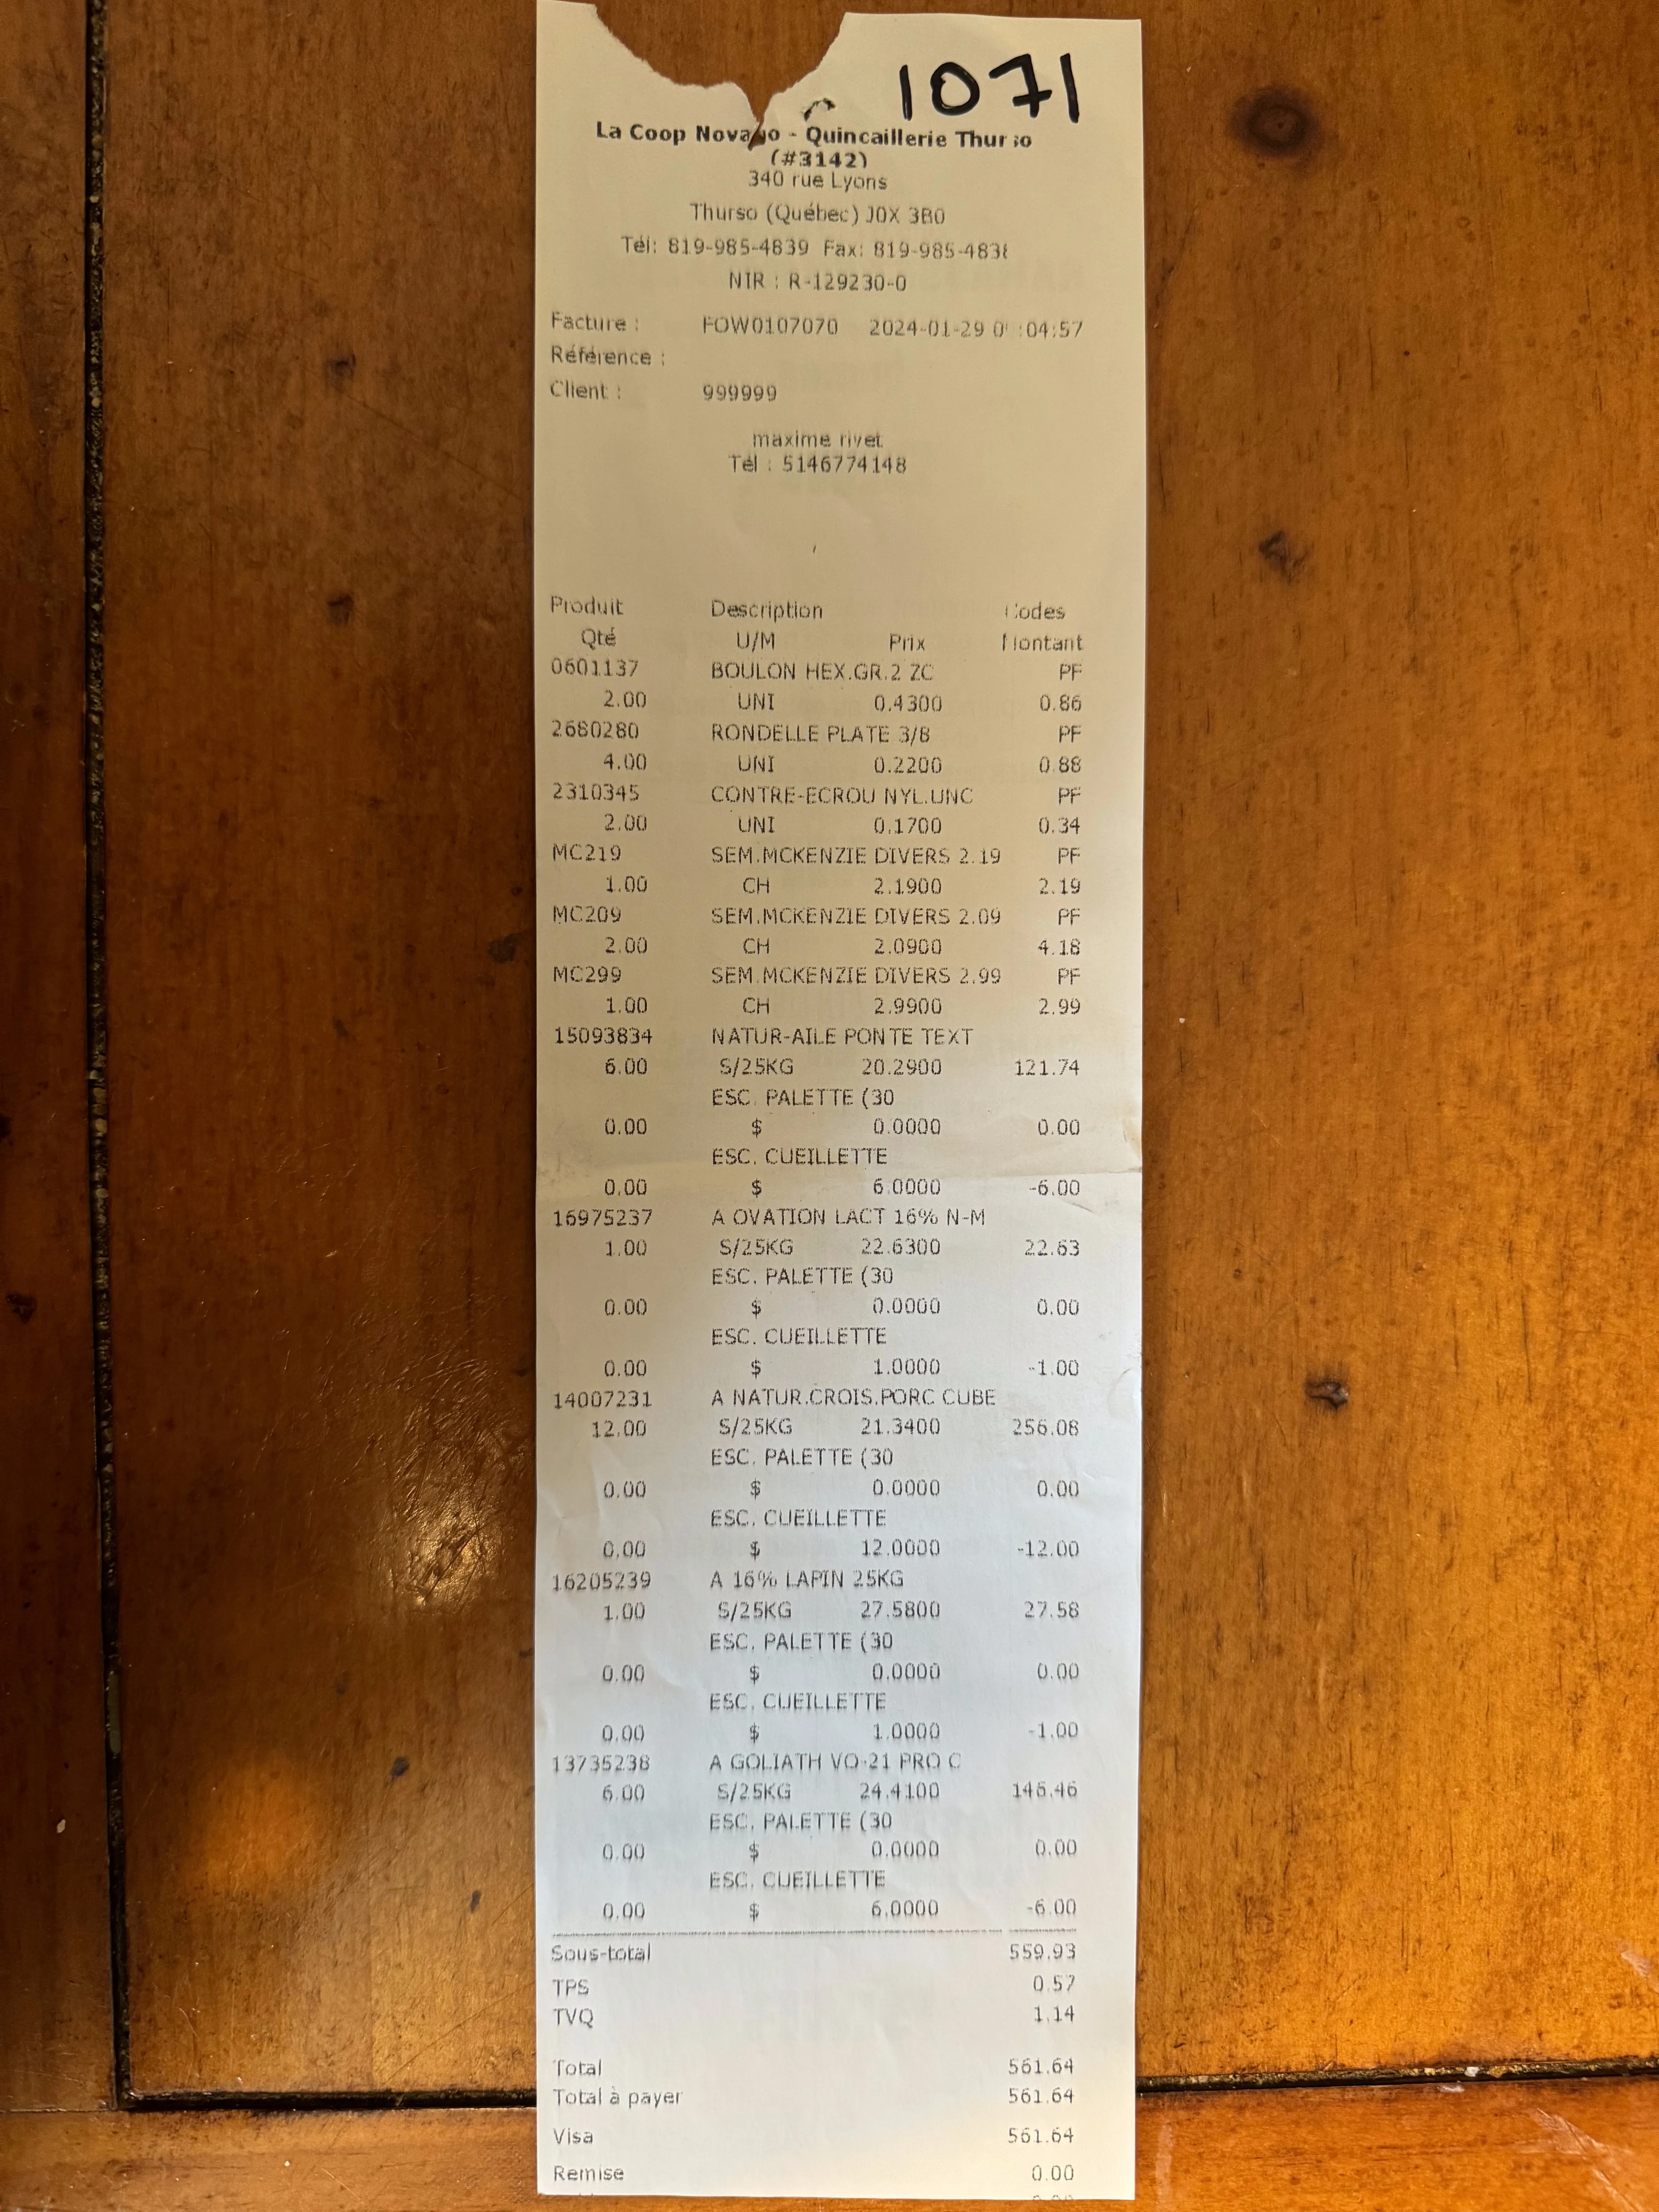

In [32]:
t.show(3)

In [33]:
t.add_column(ground_truth = pxt.Json)
updates = [
    {'receipt_path': 'images/receipts/IMG_2160.jpg', 'ground_truth': {'before_tax_total': 39.23, 'after_tax_total': 45.1}},
    {'receipt_path': 'images/receipts/IMG_2161.jpg', 'ground_truth': {'before_tax_total': 82.74, 'after_tax_total': 95.13}},
    {'receipt_path': 'images/receipts/IMG_2162.jpg', 'ground_truth': {'before_tax_total': 54.63, 'after_tax_total': 62.81}},
    {'receipt_path': 'images/receipts/IMG_2163.jpg', 'ground_truth': {'before_tax_total': 40.38, 'after_tax_total': 46.43}},
    {'receipt_path': 'images/receipts/IMG_2164.jpg', 'ground_truth': {'before_tax_total': 17.39, 'after_tax_total': 20.00}},
    {'receipt_path': 'images/receipts/IMG_2165.jpg', 'ground_truth': {'before_tax_total': 42.8, 'after_tax_total': 49.21}},
    {'receipt_path': 'images/receipts/IMG_2166.jpg', 'ground_truth': {'before_tax_total': 559.93, 'after_tax_total': 561.64}},
    {'receipt_path': 'images/receipts/IMG_2167.jpg', 'ground_truth': {'before_tax_total': 77.18, 'after_tax_total': 88.74}},
    {'receipt_path': 'images/receipts/IMG_2168.jpg', 'ground_truth': {'before_tax_total': 53.06, 'after_tax_total': 61.00}},
    {'receipt_path': 'images/receipts/IMG_2169.jpg', 'ground_truth': {'before_tax_total': None, 'after_tax_total': 12.64}}
]
t.batch_update(updates)

Added 10 column values with 0 errors.
Inserting rows into `receipts`: 10 rows [00:00, 949.20 rows/s]


10 rows updated.

In [34]:
@pxt.udf
def metric_udf(gt: dict, pred: dict) -> float:
    return metric(ReceiptTotals(**gt), ReceiptTotals(**pred))

In [35]:
t.add_computed_column(is_same = metric_udf(t.ground_truth, t.extraction))
t.select(
    t.ground_truth.before_tax_total,
    t.extraction.before_tax_total,
    t.ground_truth.after_tax_total,
    t.extraction.after_tax_total,
    t.is_same
).head()

Added 10 column values with 0 errors.


groundtruth_beforetaxtotal,extraction_beforetaxtotal,groundtruth_aftertaxtotal,extraction_aftertaxtotal,is_same
39.23,45.1,45.1,45.1,0.
40.38,39.58,46.43,46.43,0.
559.93,559.93,561.64,561.64,1.
77.18,88.74,88.74,100.4,0.
NaN,2.32,12.64,2.64,0.
54.63,61.46,62.81,62.81,0.
42.8,49.21,49.21,51.62,0.
17.39,20.,20.,22.61,0.
53.06,61.,61.,61.,0.
82.74,85.,95.13,95.13,0.


In [36]:
t.insert(receipt_path = "images/extra_receipt.jpg",
         receipt_image = "images/extra_receipt.jpg",
         ground_truth = {
            'before_tax_total': 651.86,
            'after_tax_total': 749.47}
)

Inserting rows into `receipts`: 1 rows [00:00, 64.65 rows/s]
Inserted 1 row with 0 errors.


1 row inserted, 5 values computed.

receipt_image,extraction,is_same
,"{""after_tax_total"": 749.47, ""before_tax_total"": 651.86}",1.

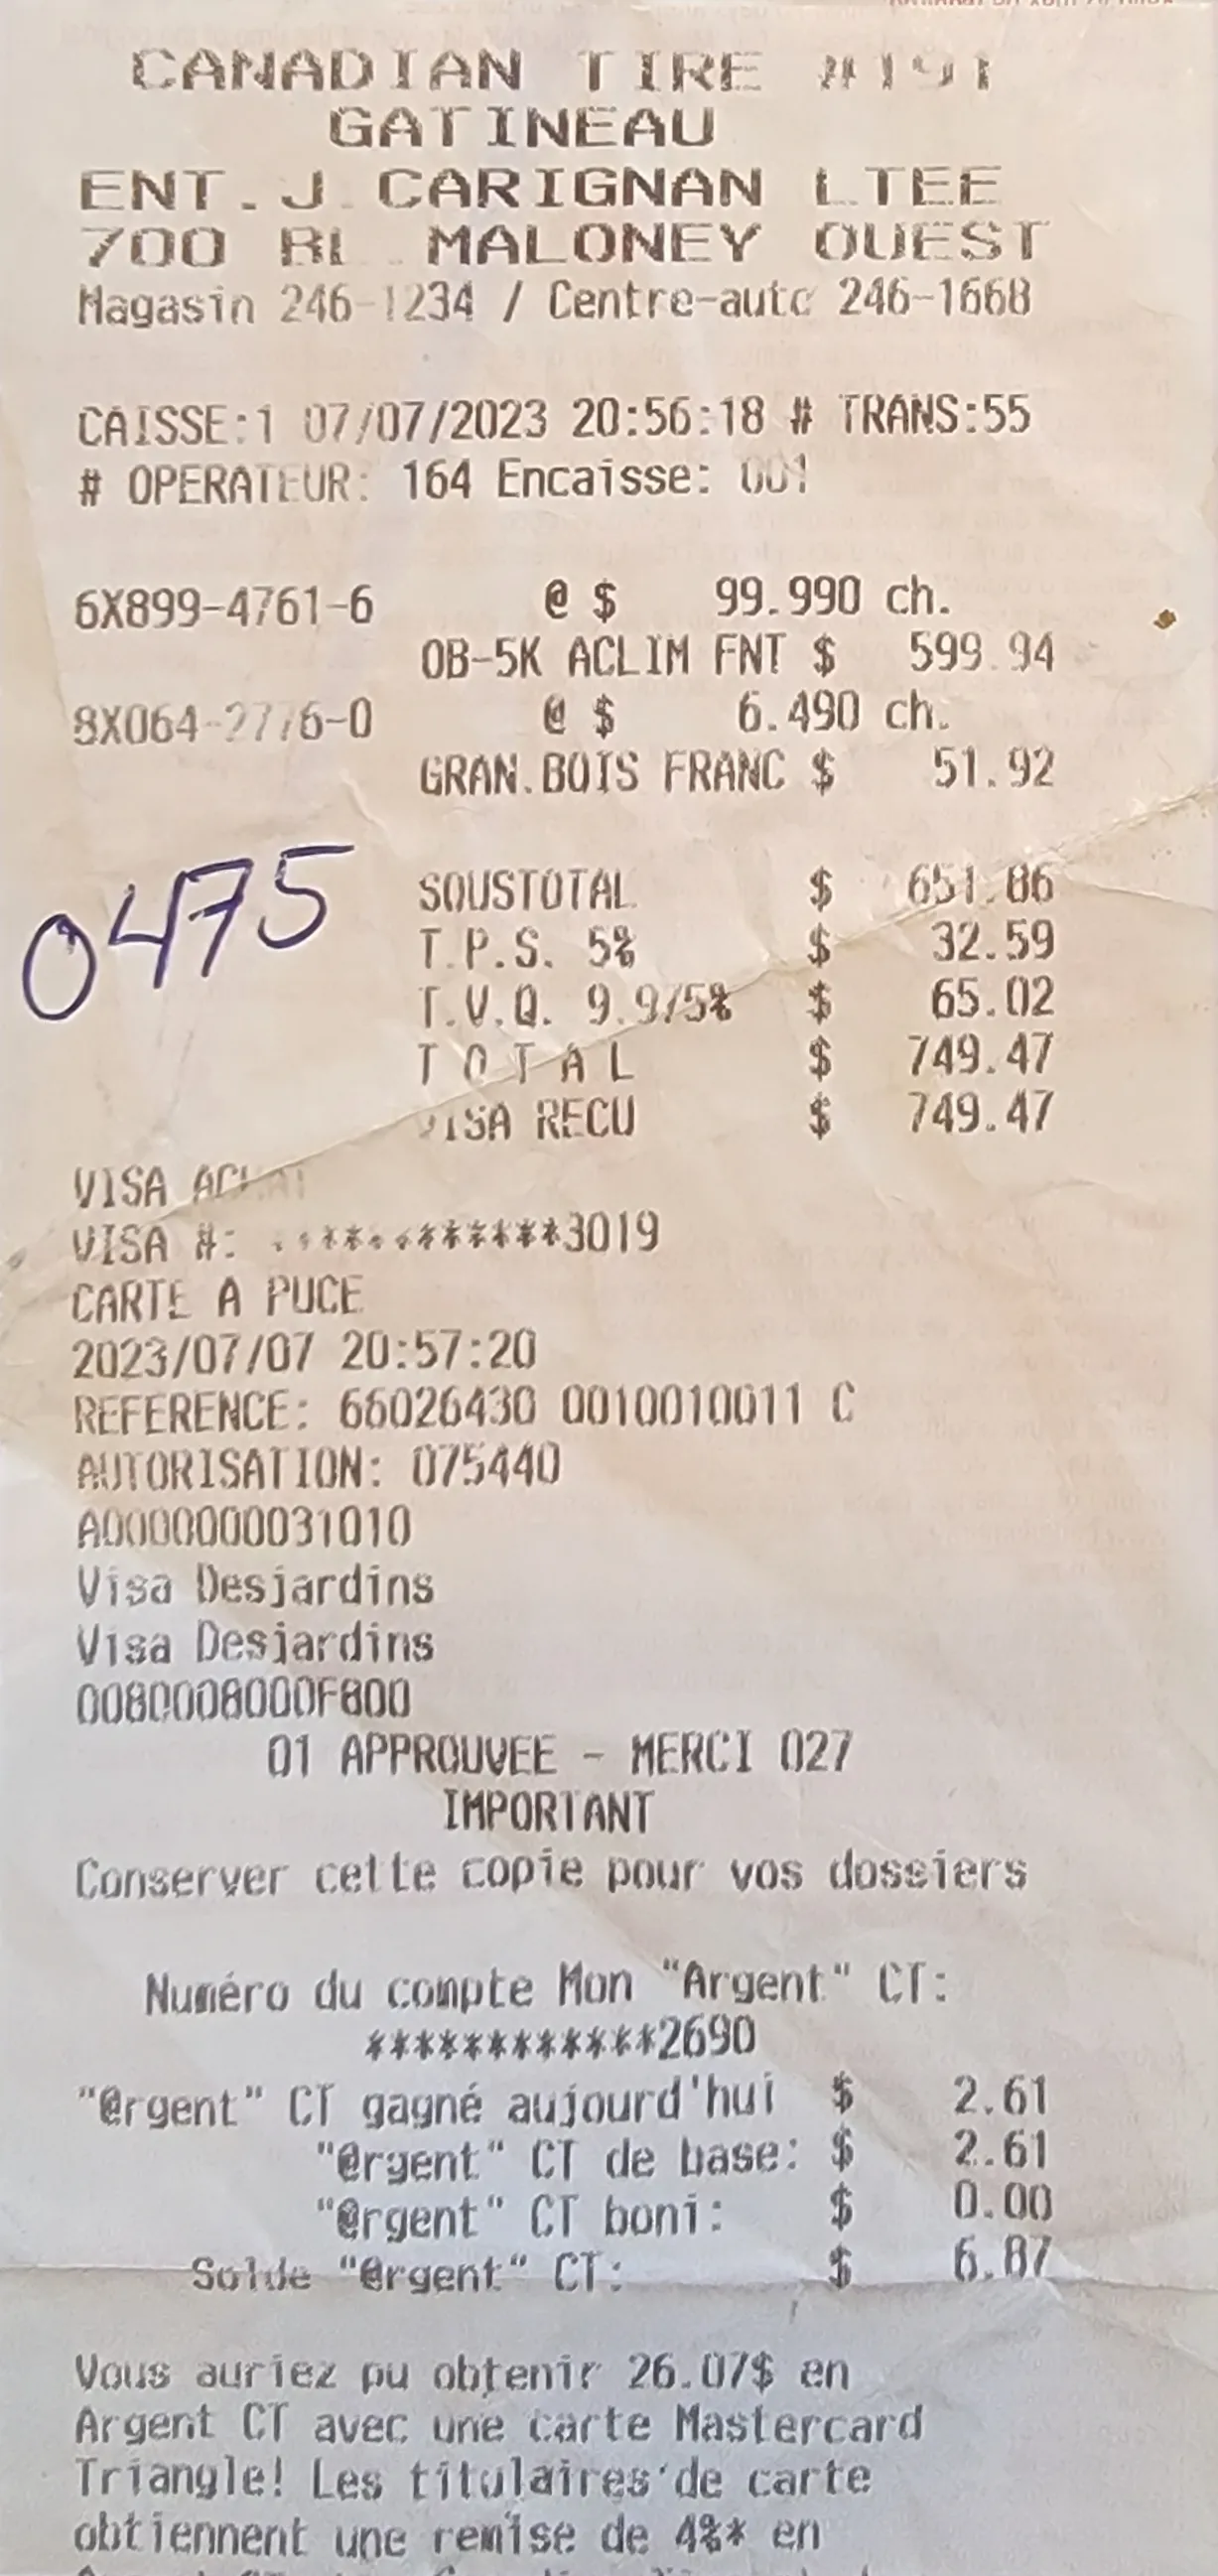

In [37]:
t.select(t.receipt_image, t.extraction, t.is_same).tail(1)

### The MIPROv2 Strategy

MIPROv2's core idea is to use a powerful LLM (the "optimizer LLM") to propose improvements to the prompts used by your AI system (the "task LLM"). It also simultaneously searches for the best few-shot examples to include in the context. It then uses Bayesian Optimization to efficiently search this joint space (Instructions x Few-Shot Examples).

The mechanism responsible for proposing new instructions is called the `GroundedProposer`. To generate effective proposals, the optimizer LLM needs context. Looking at the arguments and logic within the `GroundedProposer` implementation (provided in the DSPy source code), we can see it gathers several crucial pieces of information:

1.  **Program Awareness (`program_aware`)**: Remarkably, MIPROv2 reads the source code of your AI pipeline. It summarizes the overall goal of the program (`program_description`) and the specific role of the module (prompt) being optimized (`module_description`).
2.  **Data Awareness (`use_dataset_summary`)**: MIPROv2 analyzes the training data and creates a summary of the dataset (`dataset_description`). This helps the optimizer LLM understand the overall nature of the inputs.
3.  **Grounded Examples (`use_task_demos`)**: It selects specific input/output examples (`task_demos`) from the dataset. These often include examples where the current prompt is failing, grounding the optimization in real data.
4.  **History Awareness (`use_instruct_history`)**: It reviews previous prompt attempts and their associated scores (`previous_instructions`), allowing the optimizer LLM to learn from past successes and failures.
5.  **Exploration Strategies (`use_tip`)**: It sometimes adds randomized "tips" to the optimizer LLM (e.g., "Be creative," "Keep it concise") to explore different styles of instructions.

MIPROv2 combines all this information into a comprehensive "meta-prompt" to generate new candidate instructions.

### Our Simplified Implementation

To keep things manageable and understand the core mechanism, we will build a simplified version of this process by hand. We will focus primarily on **(3) Grounded Examples** (specifically, the receipts where our current prompt failed) and a simplified version of **(1) Program Awareness** (by explicitly stating the task goal). We will skip the automated summaries, history tracking, few-shot optimization, and Bayesian search for now.

We will create a loop that does the following:

1.  **Identify Errors**: Find the receipts where `is_same` is 0.0.
2.  **Create Context**: Use these errors (Grounded Examples) and the task goal (Program Awareness) as input for the prompt generator.
3.  **Generate New Instructions**: Use an LLM and a meta-prompt derived from the concepts in MIPROv2 to propose a new instruction.
4.  **Evaluate and Select**: Apply the new instruction, calculate the score, and keep the best prompt (a simple greedy search).

When we're done with this section, you will have a simplified, copy-pastable implementation of DSPy's instruction generation strategy, and hopefully, watch the performance of your LLM go up in minutes!

In [38]:
PROMPT_GENERATOR_TEMPLATE = """
You are an expert prompt optimizer. Use the information below to learn about a task that we are trying to solve using calls to an LM, then generate a new instruction that will be used to prompt a Language Model to better solve the task.

# Corresponds to program_description in DSPy
[PROGRAM SUMMARY]
The goal of the task is to extract the 'before tax total' and the 'after tax total' from images of receipts. The output must be parsable using specific XML tags.

# Corresponds to basic_instruction in DSPy
[CURRENT INSTRUCTION]
<current_prompt>
{current_prompt}
</current_prompt>

# Corresponds to task_demos in DSPy (focusing on failures)
[TASK DEMOS - FAILURES]
The current prompt fails on several examples. Here are the details (Ground Truth vs. Prediction):
<failures>
{failures}
</failures>

Analyze these failures. Why did the extraction likely fail based on the current instruction and the demos? 
Propose a new, improved instruction prompt that addresses these failures.

IMPORTANT: The new prompt MUST ensure the model outputs the results in the following XML tags:
<before_tax_total>VALUE</before_tax_total>
<after_tax_total>VALUE</after_tax_total>

# Corresponds to proposed_instruction (the output field) in DSPy
[PROPOSED INSTRUCTION]
Provide your improved instruction prompt in the <proposed_prompt> tag.
"""

In [39]:

@pxt.uda
class format_failures(func.Aggregator):
    """
    Aggregates failure cases by formatting them into a single string.
    Processes all rows from the input table.
    """
    def __init__(self):
        self.failures: list[str] = []
        self.example_num = 0

    def update(self, ground_truth: Optional[str], extraction: Optional[str]) -> None:
        # Called for each row; formats and adds the failure to the list
        self.example_num += 1
        failure_entry = (
            f"Example {self.example_num}:\n"
            f"  Ground Truth: {ground_truth}\n"
            f"  Prediction: {extraction}\n\n"
        )
        self.failures.append(failure_entry)

    def value(self) -> str:
        # Returns the final, combined string
        return "".join(self.failures)

In [40]:
import litellm

def propose_new_prompt(current_prompt, table, failures_df):
    """Proposes a new prompt using an LLM optimizer."""

    # 1. Identify Errors
    # We use Pixeltable's filter mechanism (where) to find rows where the metric failed.

    if failures_df.count() == 0:
        print("No failures found. Optimization complete.")
        return None

    # 2. Format Failures
    failures_str = failures_df.select(format_failures(table.ground_truth, table.extraction)).collect()[0]['format_failures']

    images = []
    for img in failures_df.collect()["receipt_image"]:
        buf = io.BytesIO()
        img.convert("RGB").save(buf, format="JPEG", quality=95)
        b64 = base64.b64encode(buf.getvalue()).decode()
        images.append({"type": "image_url", "image_url": {
                    "url": f"data:image/jpeg;base64,{b64}"
                }})
    # 3. Generate New Instruction
    prompt = PROMPT_GENERATOR_TEMPLATE.format(
        current_prompt=current_prompt,
        failures=failures_str
    )
    print("Calling LLM to propose a new prompt...")
    # MIPROv2 adds slight variation to temperature (T + epsilon) for exploration
    response = litellm.completion(
        model="gemini/gemini-2.5-pro", # We use a 'smarter' llm for optimization
        messages=[{"role": "user", "content": [
                {"type": "text", "text": prompt},
                *images[:3]
            ]}],
        temperature=0 # for reproducibility
    )

    return response.choices[0]["message"]["content"]

In [41]:
initial_prompt = (
"Extract the after-tax total and the before-tax total from the receipt.\n"
"Return the values inside these XML tags:\n"
"<before_tax_total>VALUE</before_tax_total>\n"
"<after_tax_total>VALUE</after_tax_total>"
)

In [42]:
optimization_response = propose_new_prompt(initial_prompt, t, t.where(t.is_same == 0.0))
optimization_response

Calling LLM to propose a new prompt...


'An analysis of the failures reveals several key patterns that the current simple prompt fails to address:\n\n1.  **Confusion Between Totals:** The most common error is the model confusing the `after_tax_total` with the `before_tax_total`. In examples 1, 3, 6, 7, and 8, the model either uses the `after_tax_total` for both fields or incorrectly identifies it as the `before_tax_total`. This indicates the model lacks a clear definition and strategy to differentiate between a "subtotal" and a "grand total".\n\n2.  **Failure to Calculate:** Many receipts, especially for simpler transactions like the gas receipts shown, do not explicitly print a "Subtotal" or "Before Tax Total" line. Instead, they show a final "Total" and list the included tax amounts separately. The ground truth `before_tax_total` is often derived by subtracting the taxes from the final total (e.g., Example 1: 45.10 - 1.96 - 3.91 = 39.23). The current prompt does not instruct the model to perform this calculation, causing i

In [43]:
import re
proposed_prompt_match = re.search(r"<proposed_prompt>(.*?)</proposed_prompt>", optimization_response, re.DOTALL)

proposed_prompt_v1 = proposed_prompt_match.group(1).strip()
print(proposed_prompt_v1)

You are an expert receipt data extraction agent. Your task is to meticulously analyze the provided receipt and extract two specific values: the total amount before taxes and the final total amount after taxes.

**Definitions and Strategy:**
1.  **`after_tax_total`**: This is the final, grand total amount paid by the customer. It is the most important figure to find. Look for keywords like 'TOTAL', 'GRAND TOTAL', 'BALANCE DUE', or the amount associated with a payment method (e.g., VISA, Mastercard, CREDIT). It is usually the largest final sum on the receipt.
2.  **`before_tax_total`**: This is the subtotal of all items *before* any sales taxes (like TPS, TVQ, GST, VAT) are added. It is often labeled 'SUBTOTAL' or 'NET'.

**Your step-by-step instructions:**
1.  First, carefully locate the `after_tax_total`. This is the final amount paid.
2.  Next, search for the `before_tax_total` (often labeled 'Subtotal').
3.  **CRITICAL RULE:** If you cannot find an explicit `before_tax_total` or 'Sub

In [44]:
from PIL import Image
from typing import Dict
import base64, io

def extract_totals_with_prompt(img: Image.Image, prompt: str) -> Dict[str, float]:
    """Extracts totals using a specified prompt."""
    # --- 1. Encode image --- (Same as before)
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=95)
    b64 = base64.b64encode(buf.getvalue()).decode()

    # --- 2. LLM call --- (Using the provided prompt)
    try:
        response = litellm.completion(
            model="groq/meta-llama/llama-4-maverick-17b-128e-instruct",
            messages=[{
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {
                        "url": f"data:image/jpeg;base64,{b64}"
                    }}
                ]
            }],
            temperature=0 # Keep temperature 0 for evaluation
        )
        raw = response.choices[0]["message"]["content"]

        # --- 3. Parse & validate ---
        # We need slightly more robust regex in case the LLM adds extra text
        before_match = re.search(r"<before_tax_total>(.*?)</before_tax_total>", raw, re.DOTALL)
        after_match = re.search(r"<after_tax_total>(.*?)</after_tax_total>", raw, re.DOTALL)

        before = before_match.group(1).strip() if before_match else None
        after = after_match.group(1).strip() if after_match else None

        # Use Pydantic for validation and cleaning
        return ReceiptTotals(before_tax_total=before, after_tax_total=after).model_dump()

    except Exception as e:
        # print(f"Error during extraction or parsing: {e}")
        # Return default empty structure on failure
        return ReceiptTotals().model_dump()

In [45]:
@pxt.udf
def extract_totals_v1_udf(img: Image.Image) -> Dict[str, float]:
    return extract_totals_with_prompt(img, proposed_prompt_v1)

t.add_computed_column(extraction_v1 = extract_totals_v1_udf(t.receipt_image))

Added 11 column values with 0 errors.


11 rows updated, 11 values computed.

receipt_path,receipt_image,extraction,ground_truth,is_same,extraction_v1
images/receipts/IMG_2160.jpg,,"{""after_tax_total"": 45.1, ""before_tax_total"": 45.1}","{""after_tax_total"": 45.1, ""before_tax_total"": 39.23}",0.,"{""after_tax_total"": 45.1, ""before_tax_total"": 45.1}"
images/receipts/IMG_2163.jpg,,"{""after_tax_total"": 46.43, ""before_tax_total"": 39.58}","{""after_tax_total"": 46.43, ""before_tax_total"": 40.38}",0.,"{""after_tax_total"": 46.43, ""before_tax_total"": 39.58}"
images/receipts/IMG_2167.jpg,,"{""after_tax_total"": 100.4, ""before_tax_total"": 88.74}","{""after_tax_total"": 88.74, ""before_tax_total"": 77.18}",0.,"{""after_tax_total"": 88.74, ""before_tax_total"": 77.18}"

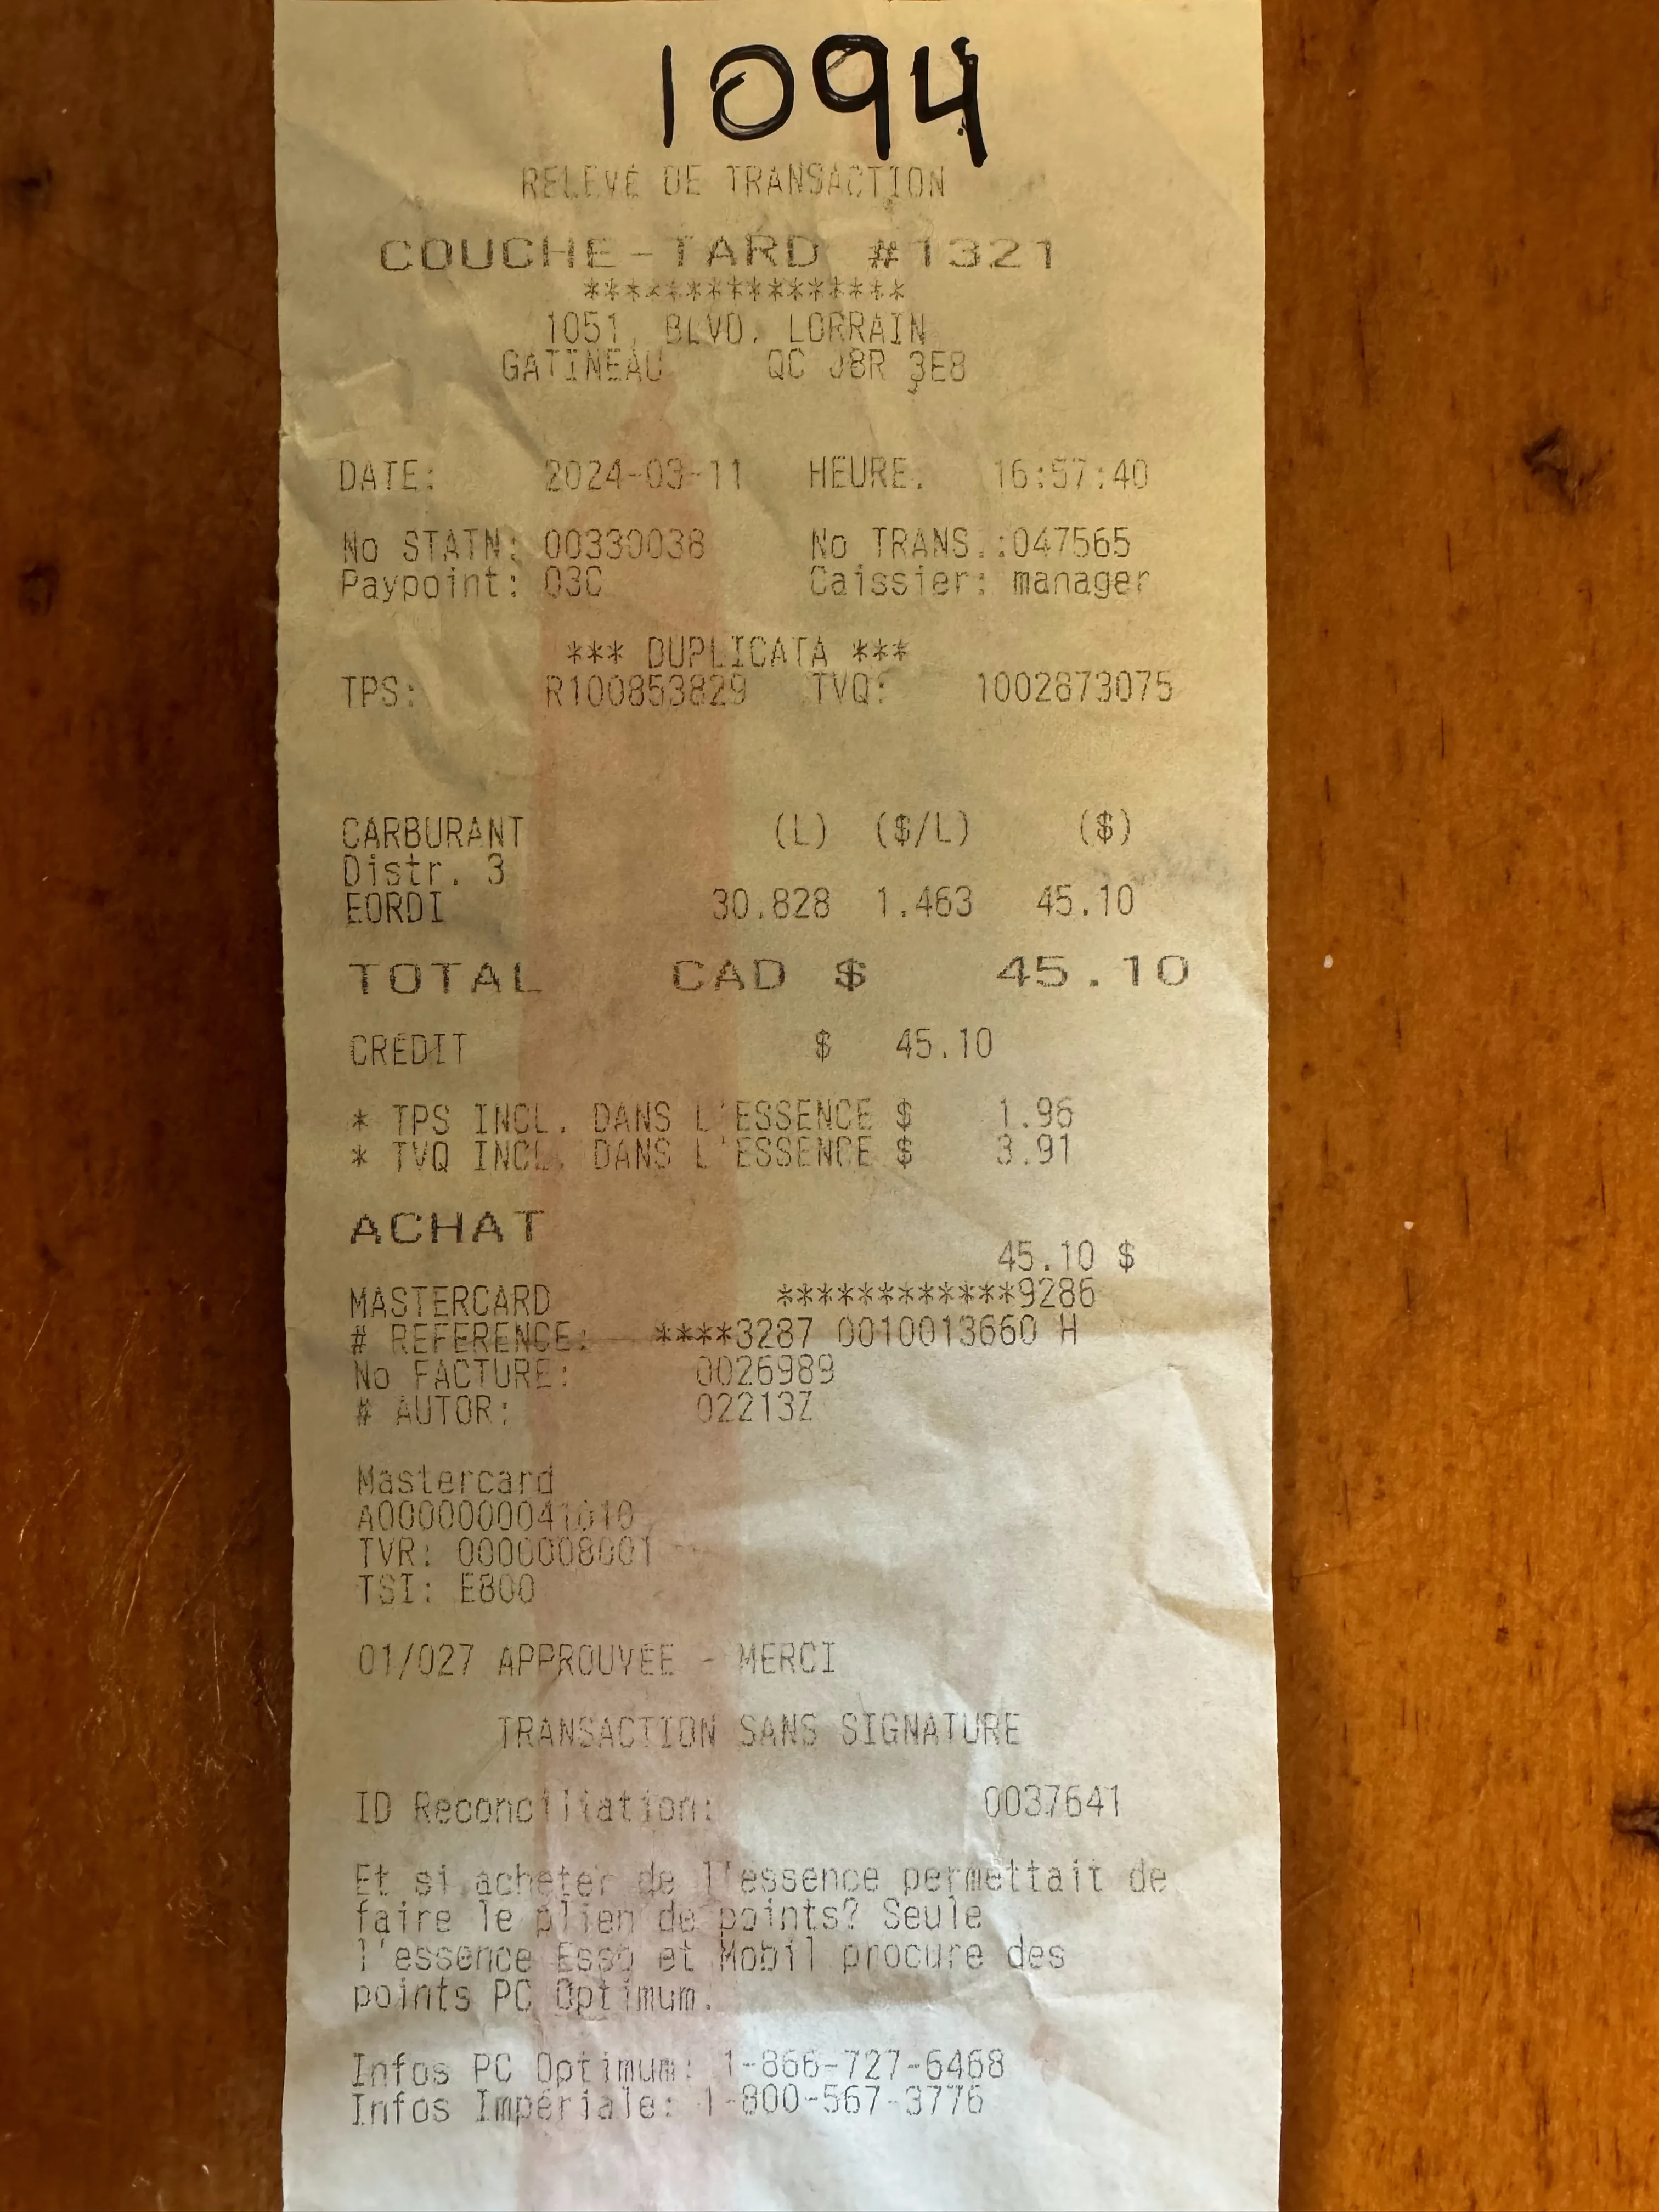
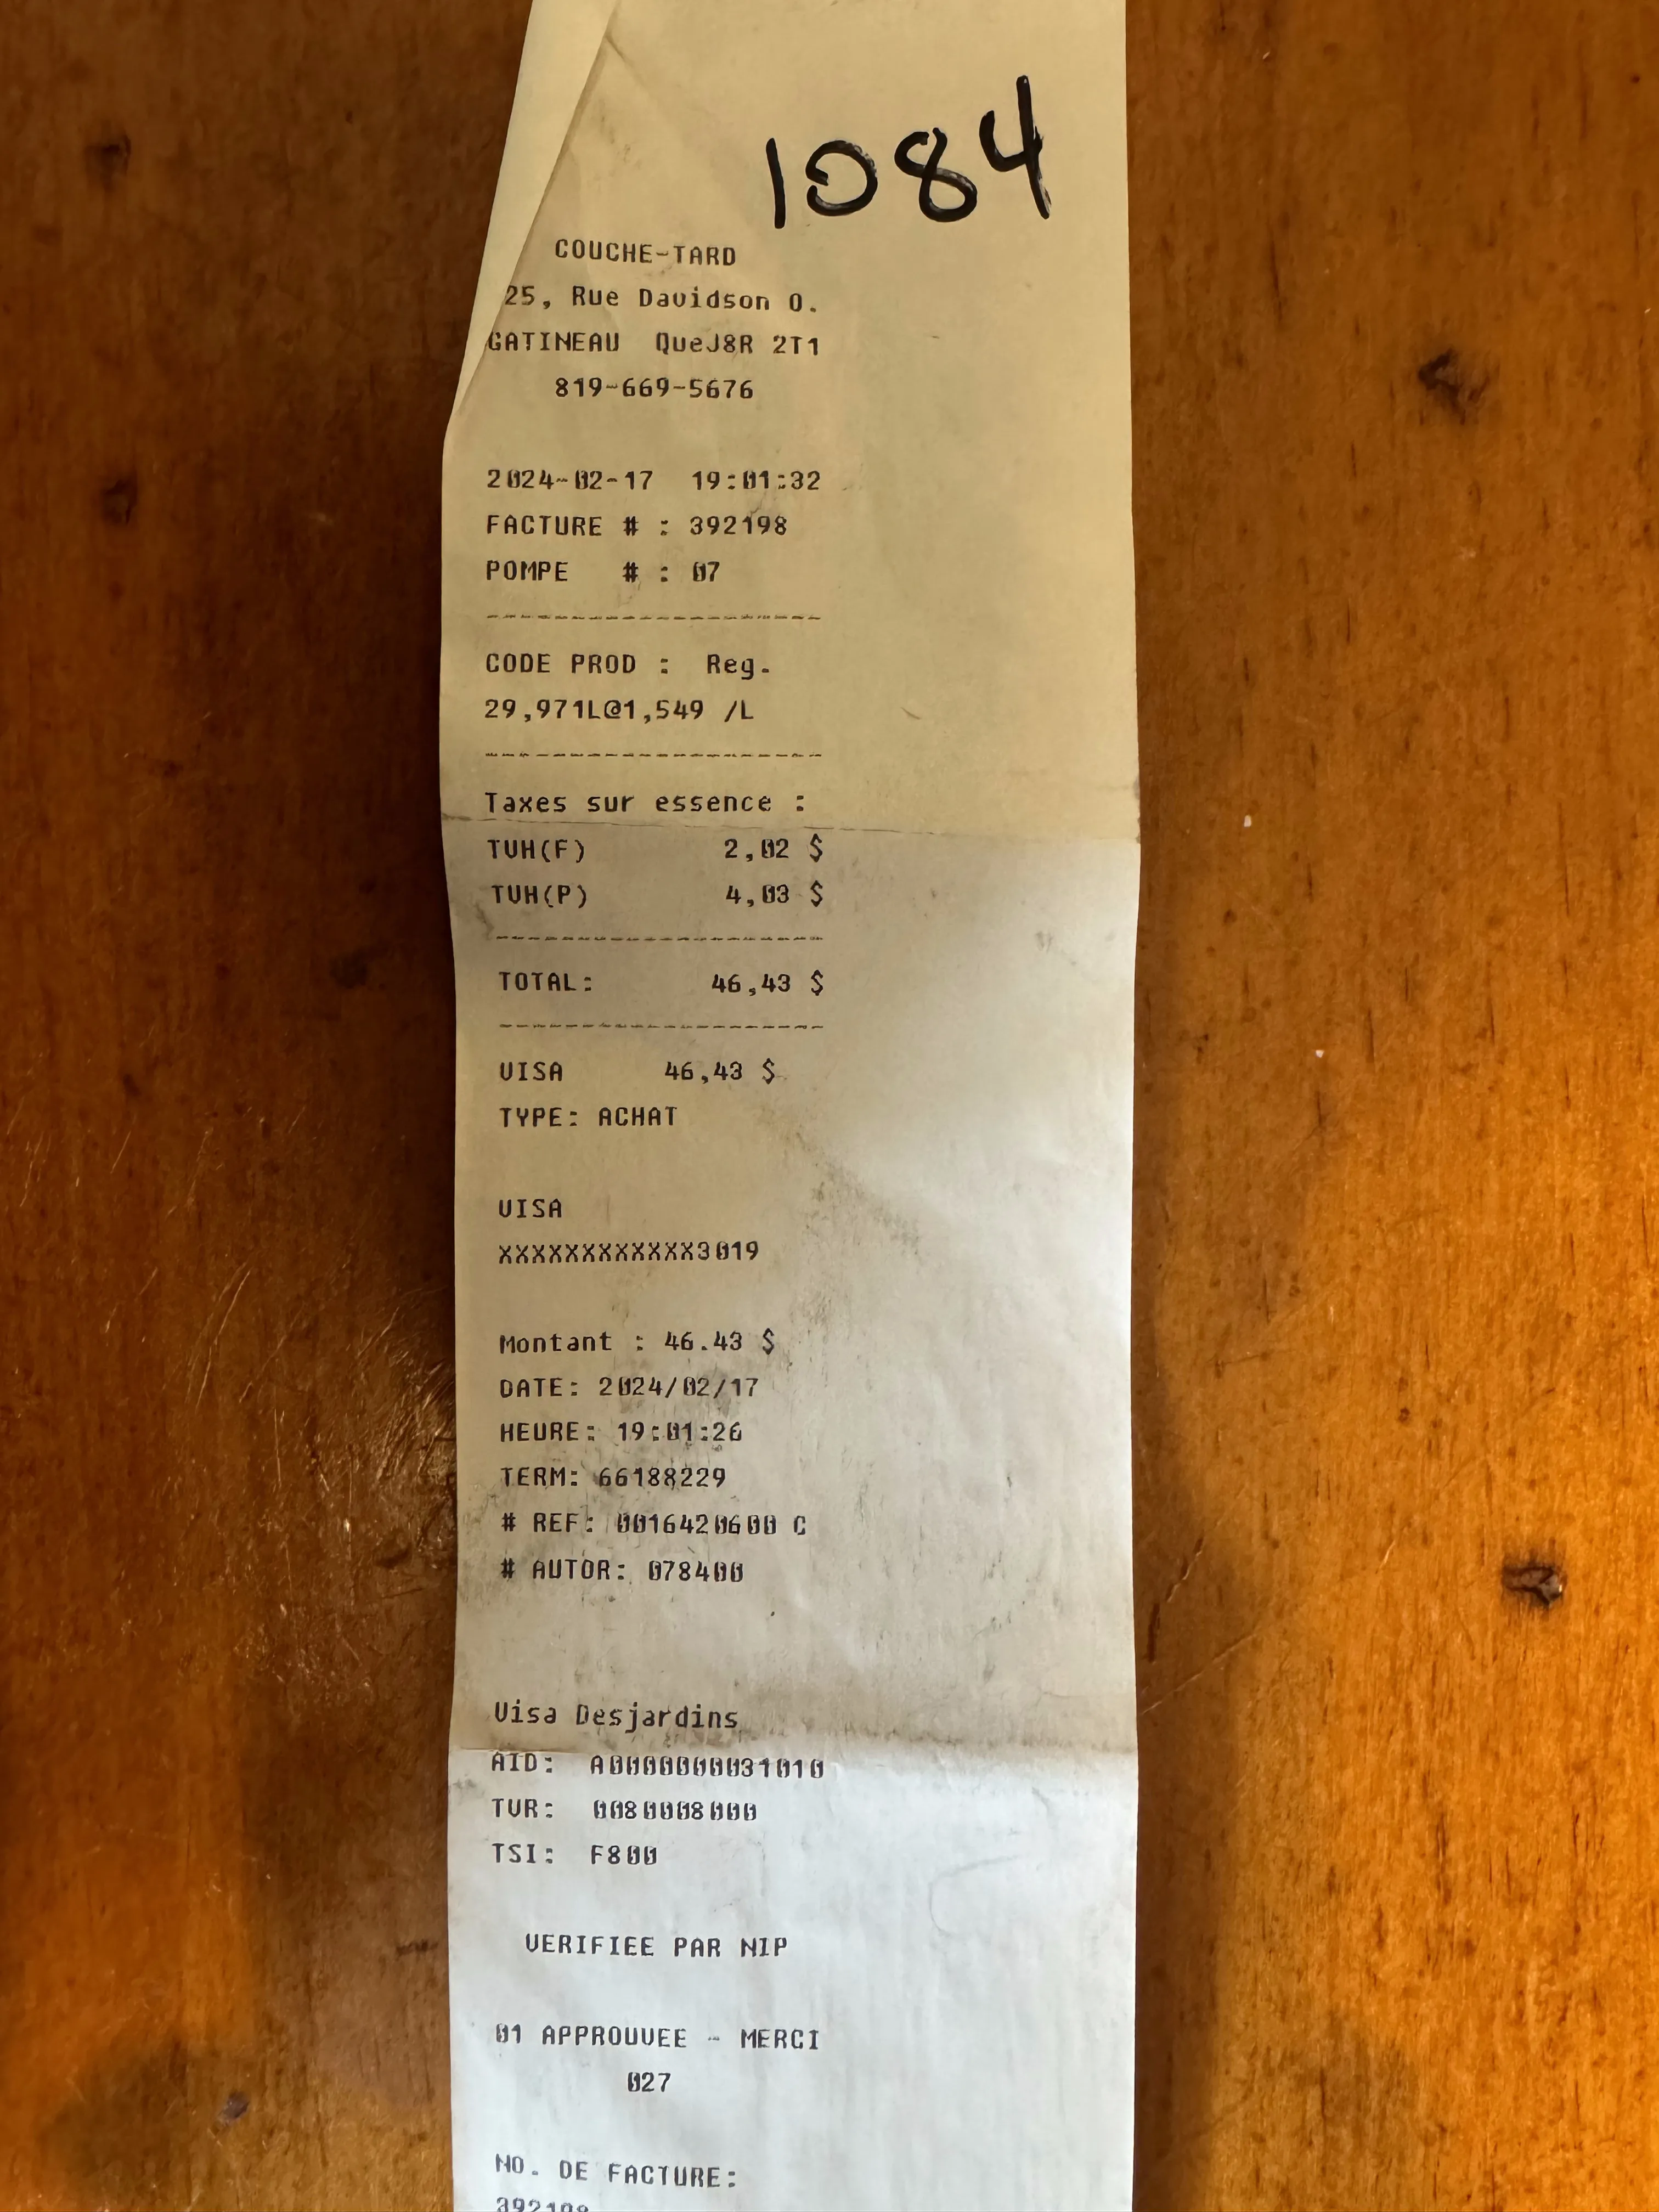
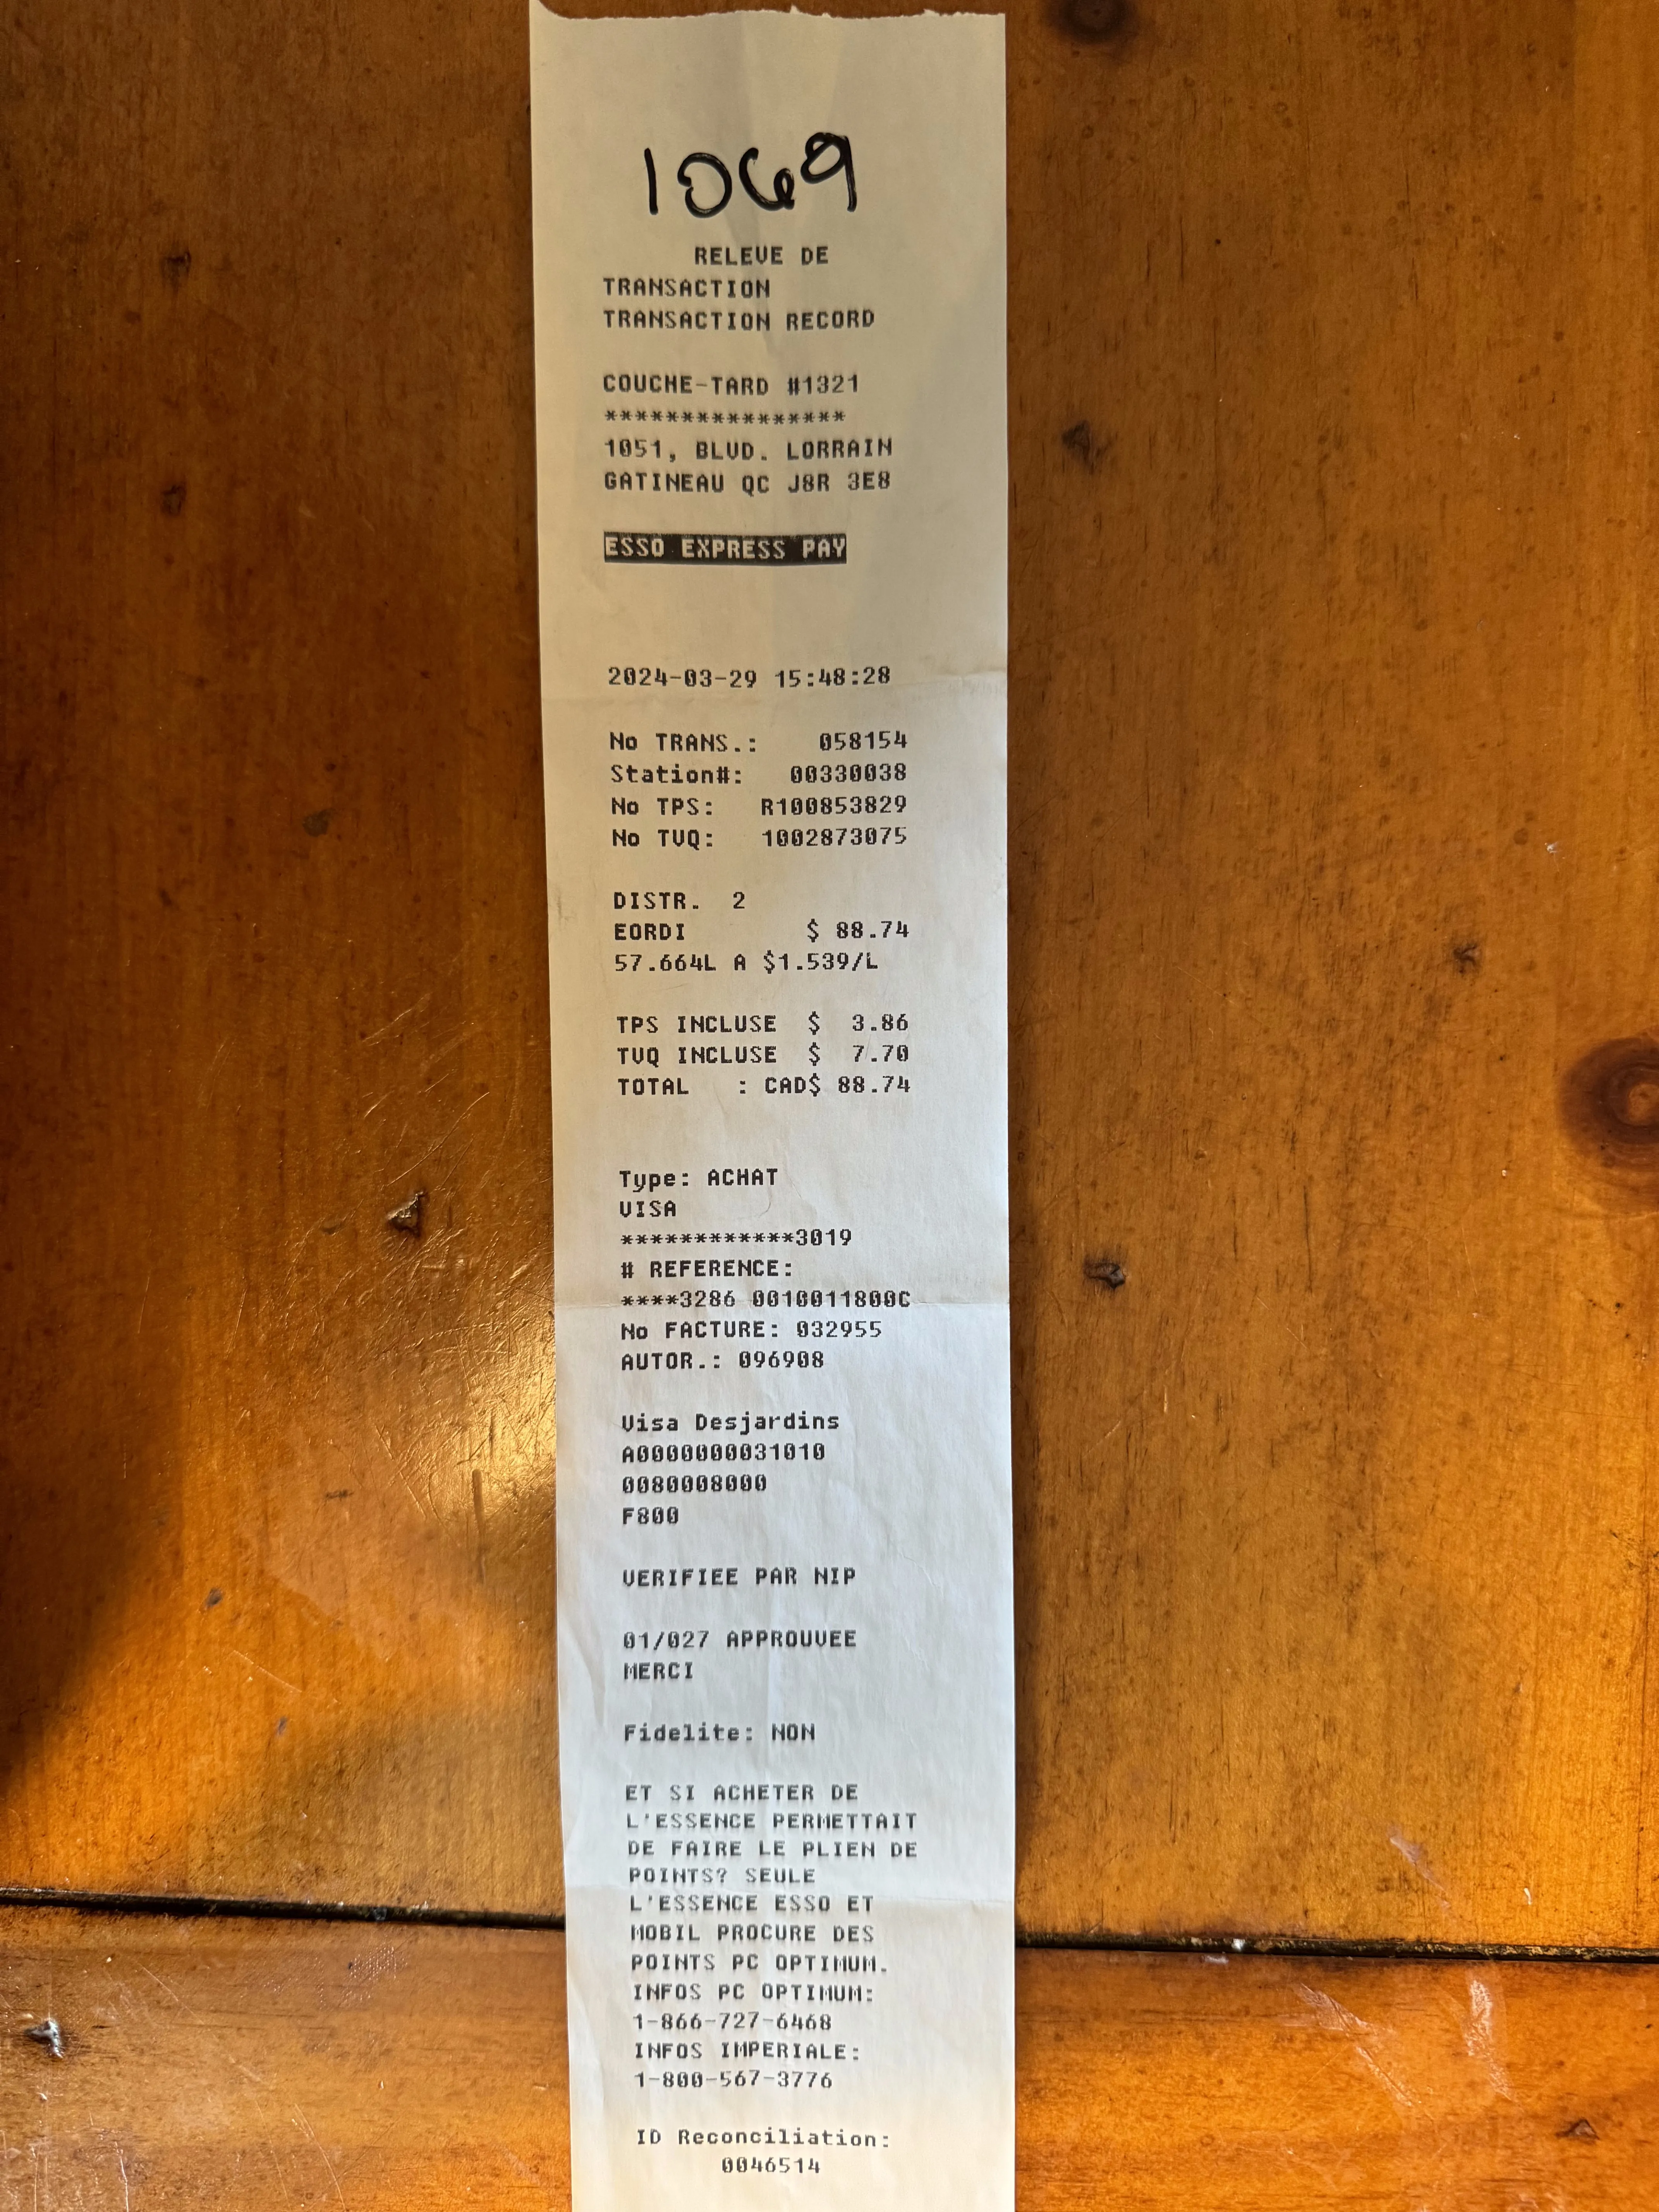

In [46]:
t.show(3)

In [47]:
t.add_computed_column(is_same_v1 = metric_udf(t.ground_truth, t.extraction_v1))

Added 11 column values with 0 errors.


11 rows updated, 22 values computed.

In [48]:
t.select(pxt.functions.mean(t.is_same_v1)).collect()

mean
0.364


4/11

In [51]:
optimization_response_v2 = propose_new_prompt(proposed_prompt_v1, t, t.where(t.is_same_v1 == 0.0))

Calling LLM to propose a new prompt...


In [52]:
proposed_prompt_match_v2 = re.search(r"<proposed_prompt>(.*?)</proposed_prompt>", optimization_response_v2, re.DOTALL)
proposed_prompt_v2 = proposed_prompt_match_v2.group(1).strip()
print(proposed_prompt_v2)

You are a highly specialized AI agent for extracting financial data from receipts. Your task is to analyze the provided receipt text and extract two key values: the total amount before taxes and the final total amount after taxes.

Follow this strict, step-by-step process to ensure maximum accuracy.

**Step 1: Identify the `after_tax_total`**

This is the final, non-negotiable amount the customer paid. It is the most important value to find. Use the following hierarchy of clues:
1.  **Payment Confirmation:** Look for the amount directly associated with a payment method line, such as `VISA`, `MASTERCARD`, `DEBIT`, `CASH`, or `Montant`. This is the strongest signal.
2.  **Grand Total Keywords:** Search for keywords like `TOTAL`, `GRAND TOTAL`, `BALANCE`, `BALANCE DUE`, `TOTAL À PAYER`.
3.  **Positional Heuristic:** This value is typically the largest final sum, usually located in the bottom half of the receipt.
4.  **Verification:** The correct `after_tax_total` should logically be the s

In [53]:
@pxt.udf
def extract_totals_v2_udf(img: Image.Image) -> Dict[str, float]:
    return extract_totals_with_prompt(img, proposed_prompt_v2)

t.add_computed_column(extraction_v2 = extract_totals_v2_udf(t.receipt_image))
t.add_computed_column(is_same_v2 = metric_udf(t.ground_truth, t.extraction_v2))

Added 11 column values with 0 errors.
Added 11 column values with 0 errors.


11 rows updated, 22 values computed.

In [54]:
t.select(t.is_same_v2).collect()

is_same_v2
1.
0.
1.
1.
0.
0.
0.
1.
1.
0.


5/11

In [55]:
t.select(t.is_same, t.is_same_v1, t.is_same_v2).show()

is_same,is_same_v1,is_same_v2
0.,0.,1.
0.,0.,0.
0.,1.,1.
1.,1.,1.
0.,0.,0.
0.,0.,0.
0.,0.,0.
0.,1.,1.
0.,1.,1.
0.,0.,0.


# Using dspy

In [56]:
import dspy
lm = dspy.LM("groq/meta-llama/llama-4-scout-17b-16e-instruct")
lm("hello")

["Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?"]

In [57]:
from pydantic import BaseModel
from typing import Optional

class ReceiptTotals(BaseModel):
    before_tax_total: Optional[float] = None
    after_tax_total:  Optional[float] = None

class OurIntent(dspy.Signature): #OurIntent can be any name we want
    """
    Extract the after-tax total and the before-tax total from the receipt.
    """
    receipt_image: dspy.Image = dspy.InputField() 
    receipt_totals: ReceiptTotals = dspy.OutputField()

In [58]:
OurIntent

OurIntent(receipt_image -> receipt_totals
    instructions='Extract the after-tax total and the before-tax total from the receipt.'
    receipt_image = Field(annotation=Image required=True json_schema_extra={'__dspy_field_type': 'input', 'prefix': 'Receipt Image:', 'desc': '${receipt_image}'})
    receipt_totals = Field(annotation=ReceiptTotals required=True json_schema_extra={'__dspy_field_type': 'output', 'prefix': 'Receipt Totals:', 'desc': '${receipt_totals}'})
)

In [59]:
dprogram = dspy.Predict(OurIntent)
dprogram.set_lm(lm)

In [60]:
dprogram

Predict(OurIntent(receipt_image -> receipt_totals
    instructions='Extract the after-tax total and the before-tax total from the receipt.'
    receipt_image = Field(annotation=Image required=True json_schema_extra={'__dspy_field_type': 'input', 'prefix': 'Receipt Image:', 'desc': '${receipt_image}'})
    receipt_totals = Field(annotation=ReceiptTotals required=True json_schema_extra={'__dspy_field_type': 'output', 'prefix': 'Receipt Totals:', 'desc': '${receipt_totals}'})
))

In [65]:
dprogram(receipt_image = dspy.Image.from_file(file_path = "images/receipts/IMG_2160.jpg"))

Prediction(
    receipt_totals=ReceiptTotals(before_tax_total=None, after_tax_total=45.1)
)

In [66]:
@pxt.udf
def dspy_baseline(img: Image.Image) -> Dict[str, float]:
    return dprogram(receipt_image = dspy.Image.from_PIL(img)).receipt_totals.model_dump()

t.add_computed_column(extraction_dspybase = dspy_baseline(t.receipt_image))

Added 11 column values with 0 errors.


11 rows updated, 11 values computed.

In [67]:
t.add_computed_column(is_same_dspybase = metric_udf(t.ground_truth, t.extraction_dspybase))

Added 11 column values with 0 errors.


11 rows updated, 22 values computed.

In [69]:
t.select(pxt.functions.sum(t.is_same_dspybase)).collect()

sum
2.


2/11

In [70]:
t.select(t.is_same, t.is_same_v1, t.is_same_v2, t.is_same_dspybase).show()

is_same,is_same_v1,is_same_v2,is_same_dspybase
0.,0.,1.,0.
0.,1.,1.,0.
1.,1.,1.,1.
0.,0.,0.,0.
0.,0.,0.,0.
0.,0.,0.,0.
0.,0.,0.,0.
0.,1.,1.,0.
0.,1.,1.,0.
0.,0.,0.,0.


In [71]:
goldset = [
    {'receipt_path': 'images/receipts/IMG_2160.jpg', 'ground_truth': {'before_tax_total': 39.23, 'after_tax_total': 45.1}},
    {'receipt_path': 'images/receipts/IMG_2161.jpg', 'ground_truth': {'before_tax_total': 82.74, 'after_tax_total': 95.13}},
    {'receipt_path': 'images/receipts/IMG_2162.jpg', 'ground_truth': {'before_tax_total': 54.63, 'after_tax_total': 62.81}},
    {'receipt_path': 'images/receipts/IMG_2163.jpg', 'ground_truth': {'before_tax_total': 40.38, 'after_tax_total': 46.43}},
    {'receipt_path': 'images/receipts/IMG_2164.jpg', 'ground_truth': {'before_tax_total': 17.39, 'after_tax_total': 20.00}},
    {'receipt_path': 'images/receipts/IMG_2165.jpg', 'ground_truth': {'before_tax_total': 42.8, 'after_tax_total': 49.21}},
    {'receipt_path': 'images/receipts/IMG_2166.jpg', 'ground_truth': {'before_tax_total': 559.93, 'after_tax_total': 561.64}},
    {'receipt_path': 'images/receipts/IMG_2167.jpg', 'ground_truth': {'before_tax_total': 77.18, 'after_tax_total': 88.74}},
    {'receipt_path': 'images/receipts/IMG_2168.jpg', 'ground_truth': {'before_tax_total': 53.06, 'after_tax_total': 61.00}},
    {'receipt_path': 'images/receipts/IMG_2169.jpg', 'ground_truth': {'before_tax_total': None, 'after_tax_total': 12.64}},
    {'receipt_path': 'images/extra_receipt.jpg', 'ground_truth': {'before_tax_total': 651.86, 'after_tax_total': 749.47}},
]
evalset = [dspy.Example(
    receipt_image = dspy.Image.from_file(i["receipt_path"]),
    receipt_totals = ReceiptTotals(
        before_tax_total = i["ground_truth"]["before_tax_total"],
        after_tax_total = i["ground_truth"]["after_tax_total"]
        )
    ).with_inputs("receipt_image") for i in goldset
]

In [72]:
evalset[0]

Example({'receipt_image': Image(url=data:image/jpeg;base64,<IMAGE_BASE_64_ENCODED(2837936)>), 'receipt_totals': ReceiptTotals(before_tax_total=39.23, after_tax_total=45.1)}) (input_keys={'receipt_image'})

In [73]:
def metric_dspy(example, pred, trace=None):
    is_btax_same = example.receipt_totals.before_tax_total == pred.receipt_totals.before_tax_total
    is_atax_same = example.receipt_totals.after_tax_total == pred.receipt_totals.after_tax_total
    return float(is_btax_same and is_atax_same)

In [ ]:
teacherp = dprogram.deepcopy()
teacherp.set_lm(lm = dspy.LM("gemini/gemini-2.5-pro"))
optimizer = dspy.MIPROv2(
    metric_dspy, 
    max_bootstrapped_demos = 0, 
    max_labeled_demos = 0, 
    prompt_model=dspy.LM("gemini/gemini-2.5-pro", max_tokens = 60000), 
    auto = "medium",
    num_threads = 6
)
dprogram_optimized = optimizer.compile(dprogram, trainset=evalset, requires_permission_to_run = False, teacher = teacherp)

In [76]:
dprogram_optimized(receipt_image = dspy.Image.from_file(file_path = "images/receipts/IMG_2160.jpg"))

Prediction(
    receipt_totals=ReceiptTotals(before_tax_total=39.23, after_tax_total=45.1)
)

In [77]:
dprogram_optimized.inspect_history()





[2025-08-24T11:35:30.244290]

System message:

Your input fields are:
1. `receipt_image` (Image):
Your output fields are:
1. `receipt_totals` (ReceiptTotals):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## receipt_image ## ]]
{receipt_image}

[[ ## receipt_totals ## ]]
{receipt_totals}        # note: the value you produce must adhere to the JSON schema: {"type": "object", "properties": {"after_tax_total": {"anyOf": [{"type": "number"}, {"type": "null"}], "default": null, "title": "After Tax Total"}, "before_tax_total": {"anyOf": [{"type": "number"}, {"type": "null"}], "default": null, "title": "Before Tax Total"}}, "title": "ReceiptTotals"}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Your task is to analyze the provided receipt image to determine the total amount before tax (`before_tax_total`) and the final total amount after tax (`after_tax_total`).
        
        To accomplish this, 

In [78]:
res = dprogram_optimized(receipt_image = dspy.Image.from_file(file_path = "images/receipts/IMG_2160.jpg"))

In [84]:
res.receipt_totals.before_tax_total

39.23

In [85]:
for name, pred in dprogram_optimized.named_predictors():
    print("================================")
    print(f"Predictor: {name}")
    print("================================")
    print("Prompt:")
    print(pred.signature.instructions)
    print("*********************************")

Predictor: self
Prompt:
Your task is to analyze the provided receipt image to determine the total amount before tax (`before_tax_total`) and the final total amount after tax (`after_tax_total`).

To accomplish this, you must follow a specific calculation process:
1.  **Identify the After-Tax Total:** First, locate the final, conclusive total amount on the receipt. This is the amount the customer paid and is often labeled 'TOTAL', 'ACHAT', or 'CREDIT'. This value is your `after_tax_total`.
2.  **Identify All Tax Amounts:** Next, carefully scan the receipt to find all individual tax amounts. Look for labels such as 'TPS', 'TVQ', 'GST', 'PST', or 'TAX'. Sum all of these individual tax values together.
3.  **Calculate the Before-Tax Total:** The `before_tax_total` is not directly listed but must be calculated. Subtract the total sum of all taxes you found in step 2 from the `after_tax_total` identified in step 1.
4.  **Provide the Output:** Present your final answer in the specified format

In [86]:
@pxt.udf
def dspy_optimized(img: Image.Image) -> Dict[str, float]:
    return dprogram_optimized(receipt_image = dspy.Image.from_PIL(img)).receipt_totals.model_dump()

t.add_computed_column(extraction_dspyopt = dspy_optimized(t.receipt_image))

Added 11 column values with 0 errors.


11 rows updated, 11 values computed.

In [88]:
t.add_computed_column(is_same_dspyopt = metric_udf(t.ground_truth, t.extraction_dspyopt))

Added 11 column values with 0 errors.


11 rows updated, 22 values computed.

In [90]:
t.select(pxt.functions.sum(t.is_same_dspyopt)).collect()

sum
5.


In [91]:
t.select(t.is_same, t.is_same_v1, t.is_same_v2, t.is_same_dspybase, t.is_same_dspyopt).show()

is_same,is_same_v1,is_same_v2,is_same_dspybase,is_same_dspyopt
0.,0.,1.,0.,1.
0.,0.,0.,0.,0.
1.,0.,0.,1.,1.
0.,1.,1.,0.,1.
0.,0.,0.,0.,0.
0.,1.,1.,0.,0.
0.,1.,1.,0.,1.
1.,1.,1.,1.,0.
0.,0.,0.,0.,0.
0.,0.,0.,0.,1.


In [92]:
dprogram_optimized.save("dspy_optimized.json")

# Few-shots auto opt

In [93]:
goldset = [
    {'receipt_path': 'images/receipts_fewshots/0433.jpg', 'ground_truth': {'before_tax_total': 20.99, 'after_tax_total': 24.13}},
    {'receipt_path': 'images/receipts_fewshots/0437.jpg', 'ground_truth': {'before_tax_total': 23.20, 'after_tax_total': 32.75}},
    {'receipt_path': 'images/receipts_fewshots/0438.jpg', 'ground_truth': {'before_tax_total': 59.22, 'after_tax_total': 68.09}},
    {'receipt_path': 'images/receipts_fewshots/0439.jpg', 'ground_truth': {'before_tax_total': 41.66, 'after_tax_total': 47.90}},
    {'receipt_path': 'images/receipts_fewshots/0440.jpg', 'ground_truth': {'before_tax_total': 42.39, 'after_tax_total': 48.74}},
    {'receipt_path': 'images/receipts_fewshots/0452.jpg', 'ground_truth': {'before_tax_total': 455.05, 'after_tax_total': 523.19}},
    {'receipt_path': 'images/receipts_fewshots/0455.jpg', 'ground_truth': {'before_tax_total': 335.57, 'after_tax_total': 385.82}},
    {'receipt_path': 'images/receipts_fewshots/0456.jpg', 'ground_truth': {'before_tax_total': 48.73, 'after_tax_total': 56.03}},
    {'receipt_path': 'images/receipts_fewshots/0475.jpg', 'ground_truth': {'before_tax_total': 651.86, 'after_tax_total': 749.47}},
    {'receipt_path': 'images/receipts_fewshots/0498.jpg', 'ground_truth': {'before_tax_total': 5.78, 'after_tax_total': 6.65}},
    {'receipt_path': 'images/receipts_fewshots/0502.jpg', 'ground_truth': {'before_tax_total': 25.96, 'after_tax_total': 29.85}},
    {'receipt_path': 'images/receipts_fewshots/0512.jpg', 'ground_truth': {'before_tax_total': 418.40, 'after_tax_total': 481.06}},
]
trainset = [dspy.Example(
    receipt_image = dspy.Image.from_file(i["receipt_path"]),
    receipt_totals = ReceiptTotals(
        before_tax_total = i["ground_truth"]["before_tax_total"],
        after_tax_total = i["ground_truth"]["after_tax_total"]
        )
    ).with_inputs("receipt_image") for i in goldset
]

In [94]:
lm = dspy.LM("openrouter/meta-llama/llama-4-scout", max_tokens= 64000)
dspy.configure(lm = lm)
teacherp = dprogram_optimized.deepcopy()
teacherp.set_lm(lm = dspy.LM("gemini/gemini-2.5-pro", max_tokens= 64000))
dprogram_optimized.set_lm(lm = lm)
optimizer = dspy.MIPROv2(
    metric_dspy, 
    max_bootstrapped_demos = 2, 
    max_labeled_demos = 2, 
    prompt_model=dspy.LM("gemini/gemini-2.5-pro", max_tokens= 64000), 
    task_model=lm,
    auto = "medium",
    num_threads=6)
dprogram_optimized_v2 = optimizer.compile(dprogram_optimized, trainset=trainset, valset = evalset,requires_permission_to_run = False, teacher = teacherp)

2025/08/24 11:54:34 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING MEDIUM AUTO RUN SETTINGS:
num_trials: 18
minibatch: False
num_fewshot_candidates: 12
num_instruct_candidates: 6
valset size: 11

2025/08/24 11:54:35 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2025/08/24 11:54:35 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2025/08/24 11:54:35 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=12 sets of demonstrations...


Bootstrapping set 1/12
Bootstrapping set 2/12
Bootstrapping set 3/12


 42%|██████████████████▎                         | 5/12 [00:23<00:33,  4.74s/it]


Bootstrapped 2 full traces after 5 examples for up to 1 rounds, amounting to 5 attempts.
Bootstrapping set 4/12


  8%|███▋                                        | 1/12 [00:04<00:53,  4.84s/it]


...

2025/08/24 12:07:13 INFO dspy.evaluate.evaluate: Average Metric: 4.0 / 11 (36.4%)


2025/08/24 12:07:13 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 36.36 with parameters ['Predictor 0: Instruction 5', 'Predictor 0: Few-Shot Set 0'].
2025/08/24 12:07:13 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [54.55, 36.36, 36.36, 36.36, 27.27, 27.27, 36.36, 36.36, 36.36, 27.27, 54.55, 54.55, 36.36, 45.45, 36.36, 45.45, 45.45, 36.36]
2025/08/24 12:07:13 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 54.55
2025/08/24 12:07:13 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2025/08/24 12:07:13 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 19 / 18 =====


Average Metric: 5.00 / 11 (45.5%): 100%|████████| 11/11 [00:15<00:00,  1.41s/it]

2025/08/24 12:07:31 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 11 (45.5%)


2025/08/24 12:07:32 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 45.45 with parameters ['Predictor 0: Instruction 0', 'Predictor 0: Few-Shot Set 1'].
2025/08/24 12:07:32 INFO dspy.teleprompt.mipro_optimizer_v2: Scores so far: [54.55, 36.36, 36.36, 36.36, 27.27, 27.27, 36.36, 36.36, 36.36, 27.27, 54.55, 54.55, 36.36, 45.45, 36.36, 45.45, 45.45, 36.36, 45.45]
2025/08/24 12:07:32 INFO dspy.teleprompt.mipro_optimizer_v2: Best score so far: 54.55
2025/08/24 12:07:32 INFO dspy.teleprompt.mipro_optimizer_v2: =========================


2025/08/24 12:07:32 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 54.55!


In [95]:
for name, pred in dprogram_optimized_v2.named_predictors():
    print("================================")
    print(f"Predictor: {name}")
    print("================================")
    print("Prompt:")
    print(pred.signature.instructions)
    print("================================")
    print("Demo:")
    print(pred.demos)
    print("*********************************")

Predictor: self
Prompt:
Your task is to analyze the provided receipt image to determine the total amount before tax (`before_tax_total`) and the final total amount after tax (`after_tax_total`).

To accomplish this, you must follow a specific calculation process:
1.  **Identify the After-Tax Total:** First, locate the final, conclusive total amount on the receipt. This is the amount the customer paid and is often labeled 'TOTAL', 'ACHAT', or 'CREDIT'. This value is your `after_tax_total`.
2.  **Identify All Tax Amounts:** Next, carefully scan the receipt to find all individual tax amounts. Look for labels such as 'TPS', 'TVQ', 'GST', 'PST', or 'TAX'. Sum all of these individual tax values together.
3.  **Calculate the Before-Tax Total:** The `before_tax_total` is not directly listed but must be calculated. Subtract the total sum of all taxes you found in step 2 from the `after_tax_total` identified in step 1.
4.  **Provide the Output:** Present your final answer in the specified format

# Manual program crafting

In [100]:
from pydantic import BaseModel
from typing import Optional

class ReceiptTotals(BaseModel):
    before_tax_total: Optional[float] = None
    after_tax_total:  Optional[float] = None

class OurIntent(dspy.Signature): #OurIntent can be any name we want
    """
    Your task is to analyze the provided receipt image to determine the total amount before tax (`before_tax_total`) and the final total amount after tax (`after_tax_total`).

To accomplish this, you must follow a specific calculation process:
1.  **Identify the After-Tax Total:** First, locate the final, conclusive total amount on the receipt. This is the amount the customer paid and is often labeled 'TOTAL', 'ACHAT', or 'CREDIT'. This value is your `after_tax_total`.
2.  **Identify All Tax Amounts:** Next, carefully scan the receipt to find all individual tax amounts. Look for labels such as 'TPS', 'TVQ', 'GST', 'PST', or 'TAX'. Sum all of these individual tax values together.
3.  **Calculate the Before-Tax Total:** The `before_tax_total` is not directly listed but must be calculated. Subtract the total sum of all taxes you found in step 2 from the `after_tax_total` identified in step 1.
4.  **Provide the Output:** Present your final answer in the specified format: `before_tax_total=<calculated_value> after_tax_total=<extracted_value>`.
    """
    receipt_image: dspy.Image = dspy.InputField() 
    receipt_totals: ReceiptTotals = dspy.OutputField()

In [101]:
cotprog = dspy.ChainOfThought(OurIntent)
cotprog.set_lm(dspy.LM("groq/meta-llama/llama-4-scout-17b-16e-instruct"))
evaluator = dspy.Evaluate(devset=evalset, metric=metric_dspy, num_threads=5)
evaluator(cotprog)

2025/08/24 12:17:07 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 11 (72.7%)


EvaluationResult(score=72.73, results=<list of 11 results>)

In [102]:
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression string and return the result as a string.
    
    This function takes a string containing a mathematical expression,
    evaluates it as if it were a calculator, and returns the result as a string.
    Supports basic arithmetic operations (+, -, *, /, //, %, **) and parentheses.
    
    Args:
        expression: A string containing a mathematical expression to evaluate.
                   Example: "2 + 3 * 4", "(5 + 3) ** 2", "10 / 2"
    
    Returns:
        A string representation of the evaluated result.
        If the expression is invalid, returns an error message string.
    
    Examples:
        >>> evaluate_expression("2 + 3 * 4")
        '14'
        >>> evaluate_expression("(5 + 3) ** 2")
        '64'
        >>> evaluate_expression("10 / 3")
        '3.3333333333333335'
        >>> evaluate_expression("invalid")
        'Error: invalid expression'
    
    Note:
        This function uses eval() internally, which is safe for mathematical
        expressions but should not be used with untrusted input containing
        arbitrary Python code.
    """
    try:
        # Remove whitespace for cleaner processing
        expression = expression.strip()
        
        # Evaluate the expression
        # Using eval with restricted globals/locals for safety
        result = eval(expression, {"__builtins__": {}}, {})
        
        # Convert result to string and return
        return str(result)
    
    except (SyntaxError, NameError, TypeError, ZeroDivisionError) as e:
        return f"Error: {type(e).__name__} - {str(e)}"
    except Exception as e:
        return "Error: invalid expression"


from typing import Tuple, Dict

# Tax rates
GST_RATE = 0.05
QST_RATE = 0.09975


def calculate_gst(amount: float) -> float:
    """Calculate GST (5%) on an amount."""
    return round(amount * GST_RATE, 2)


def calculate_qst(amount: float) -> float:
    """Calculate QST (9.975%) on amount + GST."""
    return round((amount + calculate_gst(amount)) * QST_RATE, 2)


def calculate_taxes(amount: float) -> Dict[str, float]:
    """
    Calculate all Quebec taxes on an amount.
    
    Args:
        amount: Pre-tax amount in CAD
        
    Returns:
        Dictionary with gst, qst, total_tax, and total
        
    Example:
        >>> calculate_taxes(100)
        {'gst': 5.0, 'qst': 10.47, 'total_tax': 15.47, 'total': 115.47}
    """
    gst = calculate_gst(amount)
    qst = calculate_qst(amount)
    return {
        'gst': gst,
        'qst': qst,
        'total_tax': round(gst + qst, 2),
        'total': round(amount + gst + qst, 2)
    }


def add_taxes(amount: float) -> float:
    """
    Add Quebec taxes to an amount.
    
    Example:
        >>> add_taxes(100)
        115.47
    """
    return round(amount * (1 + GST_RATE) * (1 + QST_RATE), 2)


def remove_taxes(total: float) -> float:
    """
    Remove Quebec taxes from a total to get pre-tax amount.
    
    Example:
        >>> remove_taxes(115.47)
        100.0
    """
    return round(total / ((1 + GST_RATE) * (1 + QST_RATE)), 2)


def split_total(total: float) -> Dict[str, float]:
    """
    Split a tax-inclusive total into components.
    
    Args:
        total: Total amount including taxes
        
    Returns:
        Dictionary with subtotal, gst, qst, and total
        
    Example:
        >>> split_total(115.47)
        {'subtotal': 100.0, 'gst': 5.0, 'qst': 10.47, 'total': 115.47}
    """
    subtotal = remove_taxes(total)
    gst = calculate_gst(subtotal)
    qst = calculate_qst(subtotal)
    return {
        'subtotal': subtotal,
        'gst': gst,
        'qst': qst,
        'total': round(total, 2)
    }


def tax_on_list(amounts: list) -> Dict[str, float]:
    """
    Calculate taxes on a list of amounts.
    
    Example:
        >>> tax_on_list([100, 200, 50])
        {'subtotal': 350, 'gst': 17.5, 'qst': 36.66, 'total': 403.66}
    """
    subtotal = sum(amounts)
    return {
        'subtotal': subtotal,
        **calculate_taxes(subtotal)
    }


def net_tax_remittance(sales: float, purchases: float) -> Dict[str, float]:
    """
    Calculate net tax remittance (tax collected - tax paid).
    
    Args:
        sales: Total sales (pre-tax)
        purchases: Total purchases (pre-tax)
        
    Returns:
        Net GST and QST to remit
        
    Example:
        >>> net_tax_remittance(10000, 5000)
        {'gst_remittance': 250.0, 'qst_remittance': 523.75, 'total_remittance': 773.75}
    """
    sales_tax = calculate_taxes(sales)
    purchases_tax = calculate_taxes(purchases)
    
    return {
        'gst_remittance': round(sales_tax['gst'] - purchases_tax['gst'], 2),
        'qst_remittance': round(sales_tax['qst'] - purchases_tax['qst'], 2),
        'total_remittance': round(sales_tax['total_tax'] - purchases_tax['total_tax'], 2)
    }


In [103]:
agentprog = dspy.ReAct(OurIntent, tools=[
    calculator, remove_taxes, split_total, calculate_taxes, add_taxes, calculate_gst, calculate_qst, calculate_taxes, net_tax_remittance, tax_on_list
])

agentprog.set_lm(dspy.LM("groq/meta-llama/llama-4-scout-17b-16e-instruct"))
evaluator = dspy.Evaluate(devset=evalset, metric=metric_dspy, num_threads=5)
res = evaluator(agentprog, display_progress=True, display_table=True)

Average Metric: 8.00 / 11 (72.7%): 100%|████████| 11/11 [00:33<00:00,  3.09s/it]

2025/08/24 12:20:21 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 11 (72.7%)


,receipt_image,example_receipt_totals,trajectory,reasoning,pred_receipt_totals,metric_dspy
0,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=39.23 after_tax_total=45.1,"{'thought_0': 'The receipt image shows a total amount of $45.10, w...","The receipt image shows a total amount of $45.10, which includes t...",before_tax_total=39.23 after_tax_total=45.1,✔️ [1.000]
1,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=82.74 after_tax_total=95.13,"{'thought_0': 'The receipt shows an after-tax total of $95.13, wit...","The receipt shows an after-tax total of $95.13, with taxes of $4.1...",before_tax_total=82.74 after_tax_total=95.13,✔️ [1.000]
2,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=54.63 after_tax_total=62.81,"{'thought_0': 'The receipt image shows a total amount of $62.81, w...","The receipt image shows a total amount of $62.81, which includes t...",before_tax_total=61.46 after_tax_total=62.81,
3,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=40.38 after_tax_total=46.43,"{'thought_0': 'The receipt image shows a total amount of $46.43, w...","The receipt image shows a total amount of $46.43, which includes t...",before_tax_total=39.58 after_tax_total=46.43,
4,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=17.39 after_tax_total=20.0,"{'thought_0': 'The receipt image shows a total amount of $20.00, w...","The receipt image shows a total amount of $20.00, which includes T...",before_tax_total=17.39 after_tax_total=20.0,✔️ [1.000]
5,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=42.8 after_tax_total=49.21,"{'thought_0': 'The receipt image shows a total amount of $49.21, w...","The receipt image shows a total amount of $49.21, which includes t...",before_tax_total=42.8 after_tax_total=49.21,✔️ [1.000]
6,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=559.93 after_tax_total=561.64,"{'thought_0': 'The receipt image shows a total amount of $561.64, ...","The receipt image shows a total amount of $561.64, which includes ...",before_tax_total=559.93 after_tax_total=561.64,✔️ [1.000]
7,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=77.18 after_tax_total=88.74,"{'thought_0': 'The receipt image shows a total amount of $88.74, w...","The receipt image shows a total amount of $88.74, which includes T...",before_tax_total=77.18 after_tax_total=88.74,✔️ [1.000]
8,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=53.06 after_tax_total=61.0,"{'thought_0': 'The receipt shows a total amount of $61.00, which i...","The receipt shows a total amount of $61.00, which includes taxes. ...",before_tax_total=53.06 after_tax_total=61.0,✔️ [1.000]
9,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=None after_tax_total=12.64,"{'thought_0': ""The receipt image shows a total amount of $2.64. Si...",The receipt image shows a total amount of $2.64. Based on the calc...,before_tax_total=2.64 after_tax_total=3.05,


In [104]:
agentprog.set_lm(dspy.LM("gemini/gemini-2.5-pro"))
res = evaluator(agentprog, display_progress=True, display_table=True)

Average Metric: 10.00 / 11 (90.9%): 100%|███████| 11/11 [01:20<00:00,  7.31s/it]

2025/08/24 12:22:35 INFO dspy.evaluate.evaluate: Average Metric: 10.0 / 11 (90.9%)


,receipt_image,example_receipt_totals,trajectory,reasoning,pred_receipt_totals,metric_dspy
0,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=39.23 after_tax_total=45.1,{'thought_0': 'The user wants me to find the total amount before t...,1. **Identify After-Tax Total:** The receipt clearly indicates the...,before_tax_total=39.23 after_tax_total=45.1,✔️ [1.000]
1,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=82.74 after_tax_total=95.13,{'thought_0': 'The user wants me to find the total amount before t...,1. **Identify After-Tax Total:** The final total amount paid is lo...,before_tax_total=82.74 after_tax_total=95.13,✔️ [1.000]
2,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=54.63 after_tax_total=62.81,{'thought_0': 'The user wants me to find the total amount before a...,1. **Identify the After-Tax Total:** The final total amount on the...,before_tax_total=54.63 after_tax_total=62.81,✔️ [1.000]
3,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=40.38 after_tax_total=46.43,{'thought_0': 'The user wants me to find the total amount before t...,"1. **Identify After-Tax Total:** The receipt clearly shows a ""TOTA...",before_tax_total=40.38 after_tax_total=46.43,✔️ [1.000]
4,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=17.39 after_tax_total=20.0,{'thought_0': 'The user wants me to find the total amount before t...,"1. **Identify After-Tax Total:** The receipt shows a line item ""TO...",before_tax_total=17.39 after_tax_total=20.0,✔️ [1.000]
5,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=42.8 after_tax_total=49.21,{'thought_0': 'The user wants me to find the total amount before t...,1. **Identify After-Tax Total:** The final total amount is explici...,before_tax_total=42.8 after_tax_total=49.21,✔️ [1.000]
6,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=559.93 after_tax_total=561.64,{'thought_0': 'The user wants me to find the total amount before t...,"1. **Identify the After-Tax Total:** The receipt clearly shows a ""...",before_tax_total=559.93 after_tax_total=561.64,✔️ [1.000]
7,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=77.18 after_tax_total=88.74,{'thought_0': 'The user wants me to find the total amount before t...,1. **Identify After-Tax Total:** The final total amount is explici...,before_tax_total=77.18 after_tax_total=88.74,✔️ [1.000]
8,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=53.06 after_tax_total=61.0,{'thought_0': 'I need to determine the total amount before tax and...,1. **Identify After-Tax Total:** The receipt shows the final amoun...,before_tax_total=53.06 after_tax_total=61.0,✔️ [1.000]
9,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=None after_tax_total=12.64,{'thought_0': 'The user wants me to find the total amount before t...,"The final total amount paid, `after_tax_total`, is identified from...",before_tax_total=10.95 after_tax_total=12.64,


In [105]:
from pydantic import BaseModel
from typing import Optional, List

class ReceiptTotals(BaseModel):
    before_tax_total: Optional[float] = None
    after_tax_total:  Optional[float] = None

class OurIntent(dspy.Signature): #OurIntent can be any name we want
    """
    Extract the after-tax total and the before-tax total from the receipt.
    """
    receipt_image: dspy.Image = dspy.InputField()
    items: List[float] = dspy.OutputField(desc = "Description and value of each money related numericals on the receipt")
    reasoning = dspy.OutputField(desc= "Thoughs on the actual before ALL tax total (None if it obviously not there)")
    receipt_totals: ReceiptTotals = dspy.OutputField()

cotprog = dspy.Predict(OurIntent)
cotprog.set_lm(dspy.LM("gemini/gemini-2.5-pro", max_tokens=20000))
res = evaluator(cotprog, display_progress=True, display_table=True)

Average Metric: 11.00 / 11 (100.0%): 100%|██████| 11/11 [00:02<00:00,  4.55it/s]

2025/08/24 12:24:32 INFO dspy.evaluate.evaluate: Average Metric: 11.0 / 11 (100.0%)


,receipt_image,example_receipt_totals,items,reasoning,pred_receipt_totals,metric_dspy
0,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=39.23 after_tax_total=45.1,"[1.463, 45.1, 45.1, 45.1, 1.96, 3.91, 45.1]",The receipt explicitly states the amount of TPS (1.96) and TVQ (3....,before_tax_total=39.23 after_tax_total=45.1,✔️ [1.000]
1,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=82.74 after_tax_total=95.13,"[1.539, 95.13, 95.13, 95.13, 4.14, 8.25, 95.13]",The receipt shows a total of 95.13. It also explicitly states the ...,before_tax_total=82.74 after_tax_total=95.13,✔️ [1.000]
2,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=54.63 after_tax_total=62.81,"[1.463, 52.47, 8.99, 61.46, 0.45, 0.9, 62.81, 62.81, 0.0, 2.28, 4....","The receipt has a line item for ""Essence"" (fuel) where the price o...",before_tax_total=54.63 after_tax_total=62.81,✔️ [1.000]
3,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=40.38 after_tax_total=46.43,"[2.02, 4.03, 46.43, 46.43, 46.43, 1.549]",The receipt shows a final total of 46.43. It also lists two tax am...,before_tax_total=40.38 after_tax_total=46.43,✔️ [1.000]
4,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=17.39 after_tax_total=20.0,"[20.0, 1.489, 0.87, 1.74, 20.0, 20.0, 80.0]","The receipt shows a ""TOTAL"" of $20.00. It also explicitly states ""...",before_tax_total=17.39 after_tax_total=20.0,✔️ [1.000]
5,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=42.8 after_tax_total=49.21,"[1.649, 49.21, 49.21, 0.0, 0.0, 0.0, 0.0, 49.21, 49.21, 0.0, 2.14,...","The receipt shows a ""Total partiel"" of 49.21 and a final ""TOTAL"" o...",before_tax_total=42.8 after_tax_total=49.21,✔️ [1.000]
6,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=559.93 after_tax_total=561.64,"[0.86, 0.88, 0.34, 2.19, 4.18, 2.99, 121.74, 0.0, -6.0, 22.63, 0.0...","The receipt clearly labels ""Sous-total"" as 559.93. Following this ...",before_tax_total=559.93 after_tax_total=561.64,✔️ [1.000]
7,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=77.18 after_tax_total=88.74,"[88.74, 1.539, 3.86, 7.7]","The receipt shows ""TPS INCLUSE"" and ""TVQ INCLUSE"", which means the...",before_tax_total=77.18 after_tax_total=88.74,✔️ [1.000]
8,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=53.06 after_tax_total=61.0,"[1.499, 61.0, 61.0, 2.65, 5.29, 61.0]",The receipt shows a final total of $61.00. It explicitly states th...,before_tax_total=53.06 after_tax_total=61.0,✔️ [1.000]
9,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=None after_tax_total=12.64,[12.64],"This is a credit card slip, not an itemized receipt. It only shows...",before_tax_total=None after_tax_total=12.64,✔️ [1.000]


In [108]:
from pydantic import BaseModel
from typing import Optional, List

class ReceiptTotals(BaseModel):
    before_tax_total: Optional[float] = None
    after_tax_total:  Optional[float] = None

class OurIntent(dspy.Signature): #OurIntent can be any name we want
    """
    From the receipt image, extract the final total (after-tax) and all listed tax amounts. Calculate the before-tax total by subtracting the sum of the taxes from the final total. Return the before-tax total and the after-tax total.
    """
    receipt_image: dspy.Image = dspy.InputField()
    items: List[float] = dspy.OutputField(desc = "Description and value of each money related numericals on the receipt")
    reasoning = dspy.OutputField(desc= "Thoughs on the actual before ALL tax total (None if it obviously not there)")
    receipt_totals: ReceiptTotals = dspy.OutputField()

cotprog = dspy.Predict(OurIntent)
cotprog.set_lm(dspy.LM("openrouter/meta-llama/llama-4-scout", max_tokens= 64000))
res = evaluator(cotprog, display_progress=True, display_table=True)

Average Metric: 8.00 / 11 (72.7%): 100%|████████| 11/11 [00:01<00:00,  5.88it/s]

2025/08/24 12:26:16 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 11 (72.7%)


,receipt_image,example_receipt_totals,items,reasoning,pred_receipt_totals,metric_dspy
0,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=39.23 after_tax_total=45.1,"[1.96, 3.91]",The before-tax total is not explicitly mentioned on the receipt. H...,before_tax_total=39.23 after_tax_total=45.1,✔️ [1.000]
1,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=82.74 after_tax_total=95.13,[95.13],"The receipt shows a total amount of $95.13, which includes TPS (Ta...",before_tax_total=82.74 after_tax_total=95.13,✔️ [1.000]
2,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=54.63 after_tax_total=62.81,"[52.47, 8.99, 0.45, 0.9, 62.81]",The Subtotal (S-Total) is 61.46. The TPS (Tax 1) is 0.45 and the T...,before_tax_total=61.46 after_tax_total=62.81,
3,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=40.38 after_tax_total=46.43,"[2.82, 4.03]",The before-tax total is not explicitly mentioned on the receipt. H...,before_tax_total=39.58 after_tax_total=46.43,
4,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=17.39 after_tax_total=20.0,"[20.0, 0.87, 1.74]","The before-tax total is not explicitly mentioned, but it can be ca...",before_tax_total=17.39 after_tax_total=20.0,✔️ [1.000]
5,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=42.8 after_tax_total=49.21,[49.21],"The before-tax total is not explicitly mentioned, but since there ...",before_tax_total=None after_tax_total=49.21,
6,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=559.93 after_tax_total=561.64,"[0.86, 0.88, 0.34, 2.19, 4.18, 2.99, 121.74, -6.0, 22.63, -1.0, 25...","The before-tax total is not explicitly listed on the receipt, but ...",before_tax_total=559.93 after_tax_total=561.64,✔️ [1.000]
7,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=77.18 after_tax_total=88.74,"[88.74, 3.86, 7.7]","The before-tax total is not explicitly mentioned, but it can be ca...",before_tax_total=77.18 after_tax_total=88.74,✔️ [1.000]
8,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=53.06 after_tax_total=61.0,"[40.691, 1.499, 61.0, 2.65, 5.29]","The before-tax total is not explicitly stated, but we can calculat...",before_tax_total=53.06 after_tax_total=61.0,✔️ [1.000]
9,"<<CUSTOM-TYPE-START-IDENTIFIER>>[{'type': 'image_url', 'image_url'...",before_tax_total=None after_tax_total=12.64,[],None,before_tax_total=None after_tax_total=12.64,✔️ [1.000]


In [109]:
cotprog.inspect_history()





[2025-08-24T12:26:16.957382]

System message:

Your input fields are:
1. `receipt_image` (Image):
Your output fields are:
1. `items` (list[float]): Description and value of each money related numericals on the receipt
2. `reasoning` (str): Thoughs on the actual before ALL tax total (None if it obviously not there)
3. `receipt_totals` (ReceiptTotals):
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## receipt_image ## ]]
{receipt_image}

[[ ## items ## ]]
{items}        # note: the value you produce must adhere to the JSON schema: {"type": "array", "items": {"type": "number"}}

[[ ## reasoning ## ]]
{reasoning}

[[ ## receipt_totals ## ]]
{receipt_totals}        # note: the value you produce must adhere to the JSON schema: {"type": "object", "properties": {"after_tax_total": {"anyOf": [{"type": "number"}, {"type": "null"}], "default": null, "title": "After Tax Total"}, "before_tax_total": {"anyOf": [{"type": "number"}, {"type": "n

In [ ]:
# Define the SimplestAdapter as before
class SimplestAdapter(dspy.Adapter):
    def __call__(self, lm, lm_kwargs, signature, demos, inputs):
        print(inputs)
        system_content = signature.instructions
        if demos:
            system_content
        messages = [
            {"role": "system", "content": system_content},
            {"role": "user", "content": inputs["prompt"]},
        ]
        outputs = lm(messages=messages, **lm_kwargs)
        return [{"generation": outputs[0]}]

# Do NOT call dspy.configure(adapter=SimplestAdapter())
# Subclass Predict to use the custom adapter only for this instance
class MyPredict(dspy.Predict):
    def forward(self, **kwargs):
        adapter = SimplestAdapter()
        with dspy.settings.context(adapter=adapter):
            return super().forward(**kwargs)